![Kenya Food Price Early Warning System](images/banner.png)

# Kenya Food Price Early Warning System


Forecasting staple food prices across Kenyan markets to give farmers, traders, and food security actors the early signal they currently lack.

## 1. Business Understanding

### 1.1 Background

Food prices in Kenya move sharply and unevenly across markets. Staples such as maize and beans respond to harvest cycles, rainfall, and supply conditions, but the people most exposed to that movement rarely see it coming.

Farmers face a timing decision every season: sell early and risk missing a better price, or hold and risk a drop. Traders and institutions face the same problem from the other side, deciding when to buy, store, or release stock.

None of this is a data problem in the strict sense. Kenya already publishes market price data through WFP and HDX. What is missing is a way to turn that historical record, combined with weather data, into a forward-looking view: where prices are likely headed, and when a market is starting to move outside its own normal range.

### 1.2 Problem Statement

Farmers, traders, and food security institutions largely make decisions on current or historical prices, not forecasts. That gap shows up as poor sell/buy timing, avoidable inventory risk, and institutional responses that arrive only after a shortage or price spike is already visible.

The core problem is not a lack of data. It is the absence of a system that combines historical prices with external drivers like weather to produce forecasts and early warnings at the market level.

### 1.3 Business Objectives

1. **Forward-looking price visibility** — forecast commodity prices two to three months ahead, per market.
2. **Early shock detection** — flag when actual prices start diverging meaningfully from what is expected.
3. **Accessible market intelligence** — surface forecasts and trends through a dashboard usable by non-technical stakeholders.
4. **Decision support at the institutional level** — provide a quantitative signal that can inform reserves, subsidies, procurement, and humanitarian response.
5. **A reproducible pipeline** — one automated path from raw data to forecast to dashboard, not a one-off analysis.

### 1.4 Stakeholder Analysis

**Smallholder farmers and cooperatives** — decide when and how much to sell; forecasts give visibility into where prices are headed before committing.

**Traders and market intermediaries** — manage inventory timing; forecasts reduce the risk of buying near a peak or holding through a decline.

**County agricultural offices and NDMA** — need early, localized signals of price stress before they escalate into broader food security concerns.

**NGOs and humanitarian organizations** — plan procurement and cash-based interventions; earlier visibility protects purchasing power against rising prices.

**National Cereals and Produce Board** — makes reserve, procurement, and stabilization decisions where a forecast is one more input.

**Urban consumers and low-income households** — most exposed to staple price swings; benefit indirectly through institutions that plan ahead on their behalf.

**Food processors and millers** — need predictable input costs for production and pricing decisions.

Across all of these, the shared need is the same: timely, market-specific signal about where food prices are heading, not just where they have been.

### 1.5 Business Success Criteria

From a business standpoint if:

- Forecasts and alerts give stakeholders information they did not already have from watching current prices.
- The anomaly detector surfaces genuine shocks without burying users in false alarms.
- A non-technical user can pick a market and commodity and immediately understand the expected price and current alert status.
- The pipeline can be refreshed with new data without significant manual rework.
- The system runs on public, freely accessible data sources, so it is not tied to a paid feed that could disappear.

### 1.6 Data Mining Goals

The technical work behind those business goals breaks into five tasks:

1. Build a **naive persistence baseline**, since any model must justify itself against it.
2. Build a **Prophet model** as the first real forecasting approach.
3. Build an **LSTM model**, both per-pair and pooled across markets and commodities, for comparison.
4. Join WFP Kenya food price data with NASA POWER weather data by market location and date.
5. Build a **residual-based anomaly detector** to flag unusual price movements.

All of this is meant to run across the full shortlist of market-commodity pairs, not a single illustrative series, since the dashboard needs coverage across markets to be useful. Results are compared using MAE and MAPE, and delivered through a Streamlit dashboard.

### 1.7 Data Mining Success Criteria

This is judged successful from a technical standpoint if:

- Forecast accuracy is measured with MAE and MAPE, consistently, across models.
- A model's usefulness is judged against the **naive persistence baseline**, not an arbitrary fixed error threshold. Beating the baseline is the bar; the baseline's actual value is established once it is computed in Modelling, not assumed here.
- The price and weather datasets join with minimal data loss.
- The anomaly detector shows a meaningfully higher flag rate during documented historical shocks than its own baseline flag rate.
- The pipeline runs end-to-end with minimal manual intervention, and produces the **same result on repeated runs** — which means every stochastic step (model initialization, training) needs to be seeded, not left to chance.
- The deployed dashboard loads reliably and reflects the pipeline's latest output.

### 1.8 Hypotheses Guiding the Analysis

- **H1:** Maize prices follow a seasonal pattern tied to harvest periods.
- **H2:** Rainfall has a measurable lagged relationship with future commodity prices.
- **H3:** Price patterns differ meaningfully across markets.
- **H4:** Maize and bean prices move together, consistent with their role as substitute staples.
- **H5:** Price volatility increases during drought periods.
- **H6:** Wholesale price changes are reflected in retail prices within one to two weeks.

These are tested, not assumed, through the EDA, feature engineering, and modelling sections that follow.

## 2. Data Understanding

This project draws on two datasets: historical food prices from WFP, and daily weather observations from NASA POWER. The goal here is to establish what each dataset contains, how it is structured, and where its quality limits are, before any cleaning or joining takes place.

### 2.1 Source of Data

| Dataset | Source | Purpose |
|---|---|---|
| WFP Kenya Food Prices | HDX (Humanitarian Data Exchange) | Historical commodity prices — the target variable |
| NASA POWER | NASA POWER API | Daily weather observations — external explanatory variables |



In [1]:
# core libraries and notebook display settings
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# record the date the data snapshot was pulled, for reproducibility
extraction_date = datetime.now().strftime("%Y-%m-%d")
print(f"Data extraction date recorded: {extraction_date}")

Data extraction date recorded: 2026-09-11


In [3]:
DATA_URL = (
    "https://data.humdata.org/dataset/"
    "e0d3fba6-f9a2-45d7-b949-140c455197ff/"
    "resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/"
    "download/wfp_food_prices_ken.csv"
)
FILENAME = "wfp_food_prices_ken.csv"


def load_food_prices():
    """
    Load the Kenya food prices dataset.

    Checks, in order: a Kaggle input copy, a saved local copy,
    then falls back to the source URL.

    Returns
    -------
    pandas.DataFrame
        Raw Kenya food prices dataset.
    """
    kaggle_root = "/kaggle/input"

    if os.path.exists(kaggle_root):
        for root, _, files in os.walk(kaggle_root):
            if FILENAME in files:
                kaggle_path = os.path.join(root, FILENAME)
                try:
                    prices_raw = pd.read_csv(kaggle_path)
                    print(f"Loaded dataset from Kaggle: {kaggle_path}")
                    return prices_raw
                except Exception as error:
                    print(f"Kaggle file could not be read: {error}")

    if os.path.exists(FILENAME):
        try:
            prices_raw = pd.read_csv(FILENAME)
            print(f"Loaded local dataset: {FILENAME}")
            return prices_raw
        except Exception as error:
            print(f"Local file could not be read: {error}")

    print("Dataset not found locally. Trying the source URL...")
    try:
        response = requests.get(DATA_URL, timeout=30)
        response.raise_for_status()
        with open(FILENAME, "wb") as file:
            file.write(response.content)
        prices_raw = pd.read_csv(FILENAME)
        print(f"Dataset downloaded and saved as '{FILENAME}'")
        return prices_raw
    except Exception as error:
        print(f"Download failed: {error}")

    if os.path.exists(FILENAME):
        print("Using the previously saved local dataset.")
        return pd.read_csv(FILENAME)

    raise FileNotFoundError(
        "Could not load the Kenya food prices dataset. "
        "Check your internet connection or provide a local copy."
    )

In [4]:
prices_raw = load_food_prices()
prices_raw.head()

Loaded local dataset: wfp_food_prices_ken.csv


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,1249.99,17.39


In [5]:
# drop the units/description row if present, then fix dtypes
def clean_price_data(prices_raw):
    """Clean and convert data types in the raw price dataset."""
    if prices_raw.iloc[0].astype(str).str.startswith("#").any():
        prices = prices_raw.iloc[1:].reset_index(drop=True)
    else:
        prices = prices_raw.copy()

    prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
    prices["price"] = pd.to_numeric(prices["price"], errors="coerce")

    if "usdprice" in prices.columns:
        prices["usdprice"] = pd.to_numeric(prices["usdprice"], errors="coerce")

    return prices


prices = clean_price_data(prices_raw)
print(f"Rows: {prices.shape[0]}, Columns: {prices.shape[1]}")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")

Rows: 27763, Columns: 16
Date range: 2006-01-15 00:00:00 to 2026-08-15 00:00:00


In [6]:
# confirm the NASA POWER API is reachable and returns the expected structure
def get_weather_sample(latitude, longitude, start="20240101", end="20240131"):
    """Fetch a short sample of daily weather data for one point."""
    power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M",
        "community": "ag",
        "longitude": longitude,
        "latitude": latitude,
        "start": start,
        "end": end,
        "format": "JSON",
    }
    response = requests.get(power_url, params=params, timeout=30)
    response.raise_for_status()
    print(f"status code {response.status_code}")
    return response.json()["properties"]["parameter"]


nairobi_lat, nairobi_lon = -1.2864, 36.8172
sample_params = get_weather_sample(latitude=nairobi_lat, longitude=nairobi_lon)
print("Parameters returned:", list(sample_params.keys()))

status code 200
Parameters returned: ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']


### 2.2 Dataset Description

The two datasets sit at different grains and are joined on market location and date.

**WFP food prices** — one row per commodity, market, and date. Each row is a single reported price for a specific pairing of item, place, and time, at either retail or wholesale level.

**NASA POWER weather** — one row per day for a given latitude/longitude point. There is no market identifier in the weather data itself; the link back to a market happens through the market's coordinates, which are already present in the price dataset.

This means the join key is not a shared ID column but a derived one: market coordinates plus date, matched to the nearest weather point.

### 2.3 Feature/Data Dictionary

**WFP Kenya Food Prices**

| Column | Type | Description | Example | Role |
|---|---|---|---|---|
| `date` | datetime64 | Date of the price observation | 2006-01-15 | Temporal |
| `admin1` | string | Top-level administrative region | Coast, Eastern | Metadata |
| `admin2` | string | Second-level administrative region | Mombasa, Kitui | Metadata |
| `market` | string | Name of the local food market | Mombasa, Kitui | Identifier / grouping |
| `market_id` | integer | Unique market identifier | 191 | Identifier |
| `latitude` | float | Market latitude | -4.05 | Geographic (join key) |
| `longitude` | float | Market longitude | 39.67 | Geographic (join key) |
| `category` | string | Broad commodity group | cereals and tubers | Metadata |
| `commodity` | string | Specific food item | Maize (white), Beans | Identifier / grouping |
| `commodity_id` | integer | Unique commodity identifier | 67 | Identifier |
| `unit` | string | Unit the price is quoted in | KG, 90 KG | Scoping |
| `priceflag` | string | Source data state | actual | Metadata |
| `pricetype` | string | Trade level | Wholesale, Retail | Scoping |
| `currency` | string | Currency | KES | Metadata |
| **`price`** | float | Price in Kenyan Shillings | 1480.00 | **Target variable (raw)** |
| `usdprice` | float | Price in USD equivalent | 20.58 | Not used |

`price` is the raw form of the target. It is standardized into `price_per_kg` during Data Preparation, once unit and trade-level scoping are resolved, and that standardized value is what the models are actually trained to predict.

**NASA POWER Weather**

| Parameter | Type | Description | Unit | Role |
|---|---|---|---|---|
| `T2M` | float | Average air temperature at 2m | °C | Predictor (used) |
| `T2M_MAX` | float | Maximum air temperature at 2m | °C | Not used |
| `T2M_MIN` | float | Minimum air temperature at 2m | °C | Not used |
| `PRECTOTCORR` | float | Bias-corrected total precipitation | mm/day | Predictor (used) |
| `RH2M` | float | Relative humidity at 2m | % | Not used |

Rainfall (`PRECTOTCORR`) and temperature (`T2M`) are the two variables this project carries forward as predictors, since they have the clearest plausible link to agricultural output and price movement.

### 2.4 Initial Data Quality Assessment

In [7]:
# column-level summary: dtype, uniqueness, missingness
data_dictionary = pd.DataFrame({
    "column": prices.columns,
    "dtype": [str(prices[col].dtype) for col in prices.columns],
    "n_unique": [prices[col].nunique() for col in prices.columns],
    "n_missing": [prices[col].isna().sum() for col in prices.columns],
    "pct_missing": [(prices[col].isna().mean() * 100).round(2) for col in prices.columns],
})
data_dictionary

,column,dtype,n_unique,n_missing,pct_missing
0,date,datetime64[us],248,0,0.00
1,admin1,str,7,62,0.22
2,admin2,str,27,62,0.22
3,market,str,226,0,0.00
4,market_id,int64,226,0,0.00
5,latitude,float64,182,62,0.22
6,longitude,float64,184,62,0.22
7,category,str,8,0,0.00
8,commodity,str,51,0,0.00
9,commodity_id,int64,51,0,0.00


In [8]:
prices[["price", "usdprice"]].describe()

,price,usdprice
count,27763.000000,27763.000000
mean,1308.392522,11.949639
std,2583.636443,22.958342
min,5.000000,0.039000
25%,70.000000,0.610000
50%,130.000000,1.030000
75%,993.000000,9.045000
max,19800.000000,184.820000


In [9]:
grain_columns = ["date", "market", "commodity", "pricetype"]
duplicate_count = prices.duplicated(subset=grain_columns).sum()

print(f"Duplicate rows at (date, market, commodity, pricetype) grain: {duplicate_count}")
print(f"Unique markets: {prices['market'].nunique()}")
print(f"Unique commodities: {prices['commodity'].nunique()}")
print(f"Unique admin1 regions: {prices['admin1'].nunique()}")

Duplicate rows at (date, market, commodity, pricetype) grain: 0
Unique markets: 226
Unique commodities: 51
Unique admin1 regions: 7


In [10]:
# confirm lat/lon exist directly in the price data, and check coverage
coordinate_columns = [col for col in prices.columns if "lat" in col.lower() or "lon" in col.lower()]
coord_check = prices.groupby("market")[coordinate_columns].nunique()

missing_coords = prices[prices["latitude"].isna()]["market"].unique()

print("Coordinate columns found:", coordinate_columns)
print(f"Markets with missing coordinates: {len(missing_coords)}")
print(missing_coords)

Coordinate columns found: ['latitude', 'longitude']
Markets with missing coordinates: 1
<ArrowStringArray>
['Hola (Tana River)']
Length: 1, dtype: str


Latitude and longitude are already present in the price dataset itself, one fixed pair per market, so no separate market-reference file is needed for the weather join.

**Summary of data quality findings:**

- **Commodity labelling:** Maize appears under five separate labels (`Maize (white)`, `Maize`, `Maize flour`, `Maize (white, dry)`, `Maize flour (white)`). These need consolidation before analysis, since treating them as unrelated commodities would understate maize's true market coverage.
- **Duplicates:** none at the (date, market, commodity, pricetype) grain.
- **Coordinates:** complete for 225 of 226 markets. Hola (Tana River) is the sole exception and will be excluded from the weather join rather than imputed.
- **Missingness:** confined to `admin1`, `admin2`, `latitude`, `longitude` — all 62 rows tied to the same single market.
- **Coverage:** the price series spans January 2006 to August 2026, a long enough window to support both long-history and short-history modelling tracks.
- **Units and trade level:** `unit` and `pricetype` are not yet standardized (13 distinct units, retail and wholesale mixed) — this is scoped and resolved explicitly in Data Preparation, not here.

The dataset is fit for the next stage. The open items above are cleanup work, not blockers.

## 3. Data Cleaning and Data Preparation

This phase turns the raw price table into a modelling-ready dataset. Commodity labels are kept as reported rather than merged, since the source data already distinguishes products, such as raw grain from flour, that behave differently in price.

Scope, coverage, and quality decisions are made explicit here so that what enters modelling is a deliberate shortlist, not whatever happened to survive incidental filtering.

### 3.1 Initial Cleaning

Row-level type coercion (parsing `date`, `price`, and `usdprice`) already happened in Data Understanding, since it was needed to profile the data honestly. The first substantive preparation step is reviewing what the `commodity` field actually contains: 51 distinct labels, some of them raw or staple products, others processed derivatives such as flour or meal. A visibility flag distinguishes the two groups. It is not used to merge products together — commodity identity is preserved throughout.

In [11]:
commodity_overview = prices["commodity"].value_counts()
is_processed = prices["commodity"].str.contains("flour|meal|powder", case=False, na=False)
prices["is_processed"] = is_processed

print(f"Total distinct commodity labels: {prices['commodity'].nunique()}")
print(f"Processed or derivative product rows: {is_processed.sum()}")
commodity_overview.head(10)

Total distinct commodity labels: 51
Processed or derivative product rows: 2815


commodity
Beans (dry)         1854
Maize (white)       1656
Maize               1518
Sugar               1401
Beans               1386
Wheat flour         1380
Salt                1362
Potatoes (Irish)    1320
Sorghum             1021
Rice (aromatic)     1017
Name: count, dtype: int64

### 3.2 Data Type Handling

`price` is only meaningful once its unit is known — 1,480 KES means something different for a kilogram of maize than for a 90 kilogram sack. Every distinct unit in the dataset is mapped to a kilogram-equivalent multiplier, covering all weight-based units observed, not just the ones maize happens to use.

In [12]:
unit_counts = prices["unit"].value_counts()
print(unit_counts)

unit
KG        14595
90 KG      4118
L          2715
50 KG      1905
200 G      1362
500 ML      804
Unit        591
64 KG       518
13 KG       470
126 KG      459
400 G       178
Head         26
Bunch        22
Name: count, dtype: int64


In [13]:
unit_to_kg = {
    "KG": 1,
    "90 KG": 90,
    "64 KG": 64,
    "50 KG": 50,
    "26 KG": 26,
    "126 KG": 126,
    "13 KG": 13,
    "200 G": 0.2,
    "400 G": 0.4,
}

prices["kg_equivalent"] = prices["unit"].map(unit_to_kg)

### 3.3 Unit Standardization

With a kilogram-equivalent defined for every weight-based unit, price becomes directly comparable across records as `price_per_kg`. Units with no weight equivalent — sold by volume or by count — are left unconverted rather than force-fit, and identified explicitly here so the next step can make a clean scope decision about them.

In [14]:
prices["price_per_kg"] = prices["price"] / prices["kg_equivalent"]

unmapped_units = prices[prices["kg_equivalent"].isna()]["unit"].unique()
print(f"Unmapped units, genuinely non-weight based: {list(unmapped_units)}")
print(f"Rows converted to price per kg: {prices['price_per_kg'].notna().sum()} out of {len(prices)}")

Unmapped units, genuinely non-weight based: ['500 ML', 'L', 'Unit', 'Bunch', 'Head']
Rows converted to price per kg: 23605 out of 27763


### 3.4 Commodity and Scope Selection

Two categories of commodity are removed before completeness or coverage is ever computed, rather than left to fail silently at the price-per-kg step several sections later.

Fuel (diesel, kerosene, petrol-gasoline) is out of scope — this is a food price project, and these three are present only because the WFP dataset tracks a broader commodity basket than food. Commodities priced in a unit with no kilogram equivalent — litres, millilitres, or a bare count — are excluded on measurement grounds, not as a data quality failure. Milk in all four varieties, vegetable oil, bananas, kale, and cabbage fall into this group: legitimate food commodities, but priced in a way a per-kilogram index was never built to handle. Filtering by unit compatibility rather than hardcoding these names also protects against any other commodity sharing the same problem.

In [15]:
FUEL_COMMODITIES = ["Fuel (diesel)", "Fuel (kerosene)", "Fuel (petrol-gasoline)"]

excluded_units = sorted(set(prices["unit"]) - set(unit_to_kg))
unit_excluded_commodities = prices[prices["unit"].isin(excluded_units)]["commodity"].unique()

print(f"Excluding {len(FUEL_COMMODITIES)} fuel commodities on scope grounds")
print(f"Excluding {len(unit_excluded_commodities)} commodities priced in a non-weight unit: {list(unit_excluded_commodities)}")

prices_scoped = prices[
    ~prices["commodity"].isin(FUEL_COMMODITIES) &
    prices["unit"].isin(unit_to_kg)
].copy()

print(f"Rows after scope filtering: {len(prices_scoped)} out of {len(prices)}")

Excluding 3 fuel commodities on scope grounds
Excluding 12 commodities priced in a non-weight unit: ['Milk (cow, pasteurized)', 'Oil (vegetable)', 'Fuel (diesel)', 'Fuel (kerosene)', 'Fuel (petrol-gasoline)', 'Bananas', 'Kale', 'Oil (vegetable, fortified)', 'Milk (UHT)', 'Cabbage', 'Milk (camel, fresh)', 'Milk (cow, fresh)']
Rows after scope filtering: 23605 out of 27763


### 3.5 Retail Price Selection

Retail is selected as the primary modelling series — a deliberate scoping decision, not an oversight. Retail is the price point that smallholder farmers, cooperatives, and urban consumers, the majority of the stakeholder groups from Section 1, actually transact on. Wholesale forecasting, more relevant to traders, NCPB, and millers, is a natural extension of the same pipeline: wholesale rows remain intact in the source data and need no new collection, only rerunning completeness and modelling against `pricetype == "Wholesale"`. That is documented here as a defined next phase, not an unaddressed gap.

In [16]:
retail = prices_scoped[prices_scoped["pricetype"] == "Retail"].copy()
wholesale_rows = prices_scoped[prices_scoped["pricetype"] == "Wholesale"]

print(f"Retail rows: {len(retail)}")
print(f"Wholesale rows: {len(wholesale_rows)}")

Retail rows: 14450
Wholesale rows: 9155


### 3.6 Missing Data / Completeness

Completeness is computed for every market-commodity pair at once, against the full months available in the retail dataset, before any threshold is chosen. This gives an honest picture of coverage before the shortlist is narrowed.

In [17]:
coverage = (
    retail
    .groupby(["market", "commodity"])["date"]
    .nunique()
    .reset_index(name="months_reported")
)

total_months_available = retail["date"].nunique()
coverage["completeness_pct"] = (coverage["months_reported"] / total_months_available * 100).round(1)

print(f"Total market-commodity pairs: {len(coverage)}")
for threshold in [30, 40, 50, 60, 70]:
    qualifying = coverage[coverage["completeness_pct"] >= threshold]
    print(f"At {threshold}% threshold: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

Total market-commodity pairs: 2021
At 30% threshold: 6 pairs, 5 markets, 3 commodities
At 40% threshold: 6 pairs, 5 markets, 3 commodities
At 50% threshold: 5 pairs, 4 markets, 3 commodities
At 60% threshold: 4 pairs, 3 markets, 3 commodities
At 70% threshold: 4 pairs, 3 markets, 3 commodities


Measured against the full dataset span, almost nothing qualifies. That is because most series only began consistent reporting in late 2023 — a fixed-span measurement unfairly penalizes pairs that started later but have reported reliably since. Coverage needs to be measured against each pair's *own* active reporting window instead.

In [18]:
reporting_span = (
    retail
    .groupby(["market", "commodity"])["date"]
    .agg(first_reported="min", last_reported="max", months_reported="nunique")
    .reset_index()
)

reporting_span["active_months"] = (
    (reporting_span["last_reported"].dt.year - reporting_span["first_reported"].dt.year) * 12
    + (reporting_span["last_reported"].dt.month - reporting_span["first_reported"].dt.month)
    + 1
)

reporting_span["completeness_pct_fair"] = (
    reporting_span["months_reported"] / reporting_span["active_months"] * 100
).round(1)

for threshold in [50, 60, 70, 80, 90]:
    qualifying = reporting_span[reporting_span["completeness_pct_fair"] >= threshold]
    print(f"At {threshold}% fair completeness: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

At 50% fair completeness: 826 pairs, 176 markets, 25 commodities
At 60% fair completeness: 675 pairs, 161 markets, 25 commodities
At 70% fair completeness: 591 pairs, 159 markets, 25 commodities
At 80% fair completeness: 524 pairs, 153 markets, 25 commodities
At 90% fair completeness: 499 pairs, 149 markets, 25 commodities


### 3.7 Historical Coverage

Sufficient observations are not the same as sufficient history. Detecting a genuine seasonal pattern requires seeing it repeat across multiple years, so pairs are classified by both fair completeness and years of active history. Deeper-history pairs are routed to Prophet, which needs multiple seasonal cycles to be reliable; shorter but still-consistent pairs are routed to LSTM instead of being discarded.

In [19]:
reporting_span["years_active"] = (
    (reporting_span["last_reported"] - reporting_span["first_reported"]).dt.days / 365.25
).round(1)

MIN_YEARS_ACTIVE = 1.0

long_history = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] >= 3)
].copy()

recent_only = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] >= MIN_YEARS_ACTIVE) &
    (reporting_span["years_active"] < 3)
].copy()

insufficient_data = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] < MIN_YEARS_ACTIVE)
]

print(f"Long history pairs (3+ years): {len(long_history)}")
print(f"Recent only pairs (1 to 3 years): {len(recent_only)}")
print(f"Insufficient data pairs (under 1 year, excluded): {len(insufficient_data)}")

Long history pairs (3+ years): 100
Recent only pairs (1 to 3 years): 33
Insufficient data pairs (under 1 year, excluded): 542


Together, the long-history and recent-only groups define the full modelling scope. Each pair keeps its original commodity label, market, and price type — nothing is merged.

In [20]:
long_history["model_track"] = "prophet"
recent_only["model_track"] = "lstm"

shortlist = pd.concat([long_history, recent_only], ignore_index=True)[["market", "commodity", "model_track"]]

print(f"Total shortlisted market-commodity pairs: {len(shortlist)}")
print(f"Unique markets: {shortlist['market'].nunique()}")
print(f"Unique commodities: {shortlist['commodity'].nunique()}")

Total shortlisted market-commodity pairs: 133
Unique markets: 26
Unique commodities: 14


In [21]:
retail["kg_equivalent"] = retail["unit"].map(unit_to_kg)
retail["price_per_kg"] = retail["price"] / retail["kg_equivalent"]

modeling_data = retail.merge(shortlist, on=["market", "commodity"], how="inner")
modeling_data = modeling_data[modeling_data["price_per_kg"].notna()].copy()

print(f"Modelling-ready rows: {len(modeling_data)}")

Modelling-ready rows: 6077


### 3.8 Outlier Handling

Outlier bounds are computed on the standardized `price_per_kg` field, separately per commodity — pooling different commodities together would produce meaningless bounds, the same mistake an unstandardized check would make.

In [22]:
def flag_outliers(group):
    q1, q3 = group["price_per_kg"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["price_per_kg"] < lower) | (group["price_per_kg"] > upper)]

outliers_by_commodity = (
    modeling_data
    .groupby("commodity", group_keys=True)
    .apply(flag_outliers, include_groups=False)
    .reset_index(level=0)
)

print(f"Total outliers flagged: {len(outliers_by_commodity)} out of {len(modeling_data)}")
print(outliers_by_commodity["commodity"].value_counts())

Total outliers flagged: 69 out of 6077
commodity
Meat (camel)        26
Salt                17
Beans (dry)          8
Maize                5
Maize (white)        4
Rice                 3
Potatoes (Irish)     2
Sugar                2
Meat (beef)          1
Sorghum              1
Name: count, dtype: int64


Manual inspection of the salt outliers shows a tight, plausible cluster around 90–115 KES/kg, with a tail toward 275 KES/kg concentrated in refugee-camp markets such as Kakuma, Dadaab, and Kalobeyei, where transport and supply chain costs run higher. These are genuine prices, not conversion errors — and every flagged outlier, across every commodity, is retained rather than removed, since the anomaly detection layer built later is designed specifically to act on this kind of divergence.

In [23]:
salt_outliers = outliers_by_commodity[outliers_by_commodity["commodity"] == "Salt"]
salt_outliers[["market", "date", "price", "unit", "price_per_kg"]]

,market,date,price,unit,price_per_kg
1502,Kakuma 4,2025-09-15,20.00,200 G,100.00
1508,Ethiopia (Kakuma),2025-12-15,20.00,200 G,100.00
1511,HongKong (Kakuma),2025-12-15,23.00,200 G,115.00
1516,Kakuma 3,2025-12-15,20.00,200 G,100.00
1519,Kakuma 4,2025-12-15,18.00,200 G,90.00
1570,IFO (Daadab),2024-06-15,39.26,200 G,196.30
1741,Kakuma 4,2026-03-15,16.50,200 G,82.50
3723,Kalobeyei (Village 1),2023-07-15,49.38,200 G,246.90
4410,IFO (Daadab),2024-05-15,35.98,200 G,179.90
5400,Kakuma 3,2025-08-15,55.00,200 G,275.00


An IQR flag alone can't tell a genuine market shift, where prices settle at a new level and stay there, from a transient spike that reverts, or a one-off entry error. Each flagged outlier is classified by comparing the price level immediately after the flagged date against the baseline immediately before it. This same before/after comparison logic is the direct precursor to the residual-based anomaly detector built in Section 7.

In [24]:
def classify_outlier(row, data, window=2):
    series = data[(data["market"] == row["market"]) & (data["commodity"] == row["commodity"])].sort_values("date")
    match = series[series["date"] == row["date"]]
    if match.empty:
        return "unknown"
    pos = series.index.get_loc(match.index[0])
    before = series.iloc[max(0, pos - window):pos]["price_per_kg"]
    after = series.iloc[pos + 1: pos + 1 + window]["price_per_kg"]
    if before.empty or after.empty:
        return "insufficient surrounding data"
    baseline = before.mean()
    reverted = abs(after.mean() - baseline) < abs(row["price_per_kg"] - baseline) * 0.5
    return "transient spike" if reverted else "persistent shift"

outliers_by_commodity["classification"] = outliers_by_commodity.apply(
    lambda row: classify_outlier(row, modeling_data), axis=1
)

print(outliers_by_commodity["classification"].value_counts())

classification
persistent shift                 45
transient spike                  22
insufficient surrounding data     2
Name: count, dtype: int64


No flagged outlier is removed from the modelling dataset. Transient spikes are retained as genuine historical events, reserved as informal validation cases for the anomaly detector built later. Persistent shifts are retained too, though a sample was manually reviewed to rule out unit or entry errors masquerading as real shifts, since the two produce an identical pattern on this test. Rows with insufficient surrounding data are kept but not treated as evidence either way.

### 3.9 Dataset Integration

With the shortlist finalized, daily rainfall and temperature are retrieved from the NASA POWER API for every shortlisted market's coordinates, across the full date range needed for modelling. Weather is recorded daily but price is recorded monthly, so weather is aggregated to a monthly grain per market before joining — rainfall summed, temperature averaged, matching how each variable naturally accumulates over a month.

In [25]:
market_coords = modeling_data[["market", "latitude", "longitude"]].drop_duplicates()
weather_records = []
power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"




for _, row in market_coords.iterrows():
    params_loop = {
        "parameters": "T2M,PRECTOTCORR",
        "community": "ag",
        "longitude": row["longitude"],
        "latitude": row["latitude"],
        "start": "20060101",
        "end": "20260815",
        "format": "JSON",
    }
    resp = requests.get(power_url, params=params_loop, timeout=60)
    if resp.status_code == 200:
        param_data = resp.json()["properties"]["parameter"]
        df_market = pd.DataFrame({
            "date": pd.to_datetime(list(param_data["T2M"].keys()), format="%Y%m%d"),
            "temperature": list(param_data["T2M"].values()),
            "rainfall": list(param_data["PRECTOTCORR"].values()),
        })
        df_market["market"] = row["market"]
        weather_records.append(df_market)
    time.sleep(1)

weather_all = pd.concat(weather_records, ignore_index=True)

print(f"Markets retrieved: {weather_all['market'].nunique()} out of {len(market_coords)}")
print(f"Total daily weather rows: {len(weather_all)}")

Markets retrieved: 25 out of 26
Total daily weather rows: 188300


In [26]:
weather_monthly = (
    weather_all
    .set_index("date")
    .groupby("market")
    .resample("ME")
    .agg({"rainfall": "sum", "temperature": "mean"})
    .reset_index()
)

print(f"Monthly weather rows: {len(weather_monthly)}")
print(f"Markets represented: {weather_monthly['market'].nunique()}")

Monthly weather rows: 6200
Markets represented: 25


Cleaned monthly prices are joined to the lagged monthly weather on market and date. The weather table's own `date` column is dropped before merging — both tables otherwise carry a column named `date`, which would silently become `date_x`/`date_y` and break every downstream step that references `date` directly.

In [27]:
modeling_data["date_month"] = modeling_data["date"].values.astype("datetime64[M]")
weather_monthly["date_month"] = weather_monthly["date"].values.astype("datetime64[M]")
weather_features = weather_monthly.drop(columns=["date"])

master = modeling_data.merge(
    weather_features,
    on=["market", "date_month"],
    how="left"
)

print(f"Master table rows: {len(master)}")
print(f"Rows with matched weather data: {master['rainfall'].notna().sum()}")

Master table rows: 6077
Rows with matched weather data: 6015


### 3.10 Data Preparation Summary

Three structural decisions shaped this phase. Commodity labels were kept distinct rather than merged, since WFP records raw grain and flour, for instance, as genuinely different products with different price behavior. Completeness was measured against each pair's own active reporting window rather than the full dataset span, since most series only began consistent reporting in late 2023, and a fixed-span measure would have unfairly penalized everything that started later. Units were standardized to a common price-per-kilogram basis, with weight-based units converted and genuinely non-weight units left out of weight-based analysis entirely.

The result is a shortlist of 133 market-commodity pairs across 26 markets and 14 commodities: 100 pairs with three or more years of history routed to Prophet, and 33 shorter-history pairs routed to LSTM. Outliers were identified per commodity and retained rather than removed, since the anomaly detection layer is designed to act on genuine divergence, not treat it as noise. Weather was retrieved, aggregated to monthly, lagged by three and four months, and joined to price, producing a master table of 6,077 rows with a 98.98% weather match rate — the one shortlisted market without a match, Hola (Tana River), lacks coordinates in the source data.

Whether that three- and four-month rainfall lag actually holds up is tested properly in Exploratory Data Analysis, once weather and price share a genuinely matched market and date for every row.

## 4. Exploratory Data Analysis

With scope, units, and coverage settled in Data Preparation, the data is now genuinely comparable across markets and commodities. This section looks for the patterns the project's hypotheses actually depend on: seasonality, market-to-market differences, and any lagged relationship between weather and price.

Maize and beans anchor most of the analysis below, since they carry the deepest coverage and sit at the center of the business objectives from Section 1.

### 4.1 Univariate Analysis

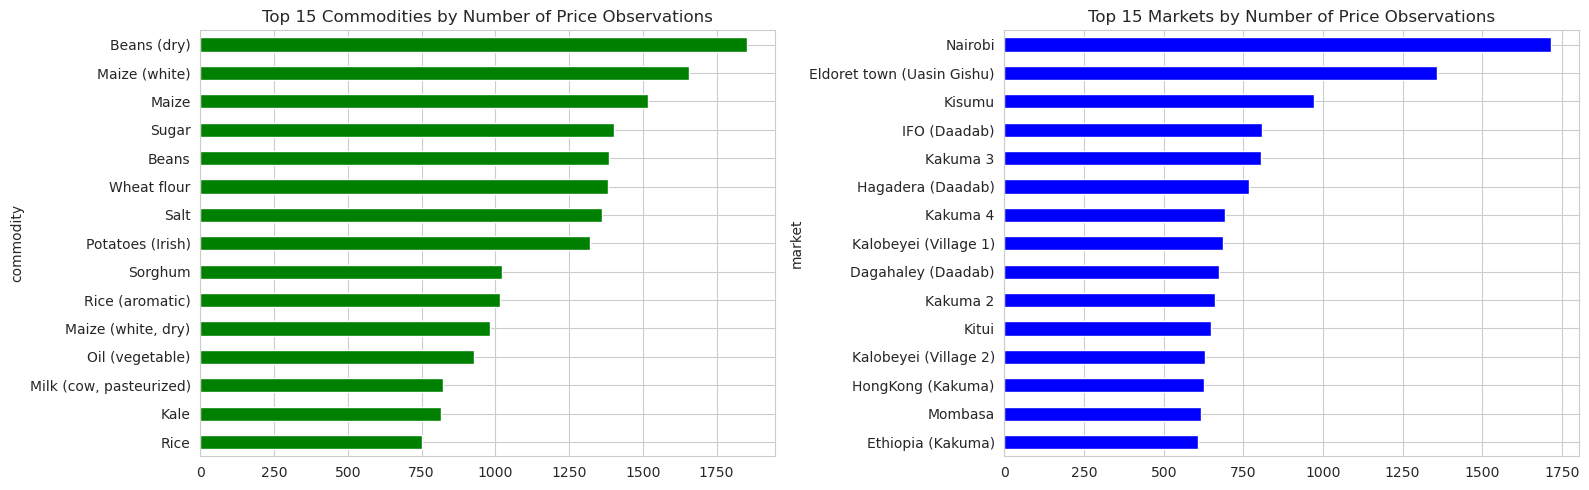

In [28]:
# distribution of price observations across commodities and markets
commodity_counts = prices["commodity"].value_counts().head(15)
market_counts = prices["market"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

commodity_counts.plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Top 15 Commodities by Number of Price Observations")
axes[0].invert_yaxis()

market_counts.plot(kind="barh", ax=axes[1], color="blue")
axes[1].set_title("Top 15 Markets by Number of Price Observations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Maize and beans dominate commodity coverage, and Nairobi sits alongside a handful of other major markets at the top of observation counts — confirming they carry enough depth for individual forecasting.

In [29]:
# maize price distribution, IQR method
maize = prices[prices["commodity"] == "Maize"].copy()

q1 = maize["price"].quantile(0.25)
q3 = maize["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = maize[(maize["price"] < lower_bound) | (maize["price"] > upper_bound)]

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] KES")
print(f"Outlier observations detected: {len(outliers)} out of {len(maize)}")
outliers[["date", "market", "price"]].sort_values("price", ascending=False).head(10)

IQR bounds: [-7.88, 88.73] KES
Outlier observations detected: 24 out of 1518


,date,market,price
23557,2023-08-15,Dagahaley (Daadab),120.00
23171,2023-05-15,Ethiopia (Kakuma),100.00
24191,2024-01-15,Dagahaley (Daadab),100.00
23730,2023-09-15,HongKong (Kakuma),100.00
23719,2023-09-15,Ethiopia (Kakuma),100.00
24462,2024-03-15,HongKong (Kakuma),100.00
23485,2023-07-15,Kakuma 3,97.50
25025,2024-08-15,Dagahaley (Daadab),97.50
23206,2023-05-15,Kakuma 3,95.00
24415,2024-03-15,Dagahaley (Daadab),94.41


### 4.2 Bivariate Analysis

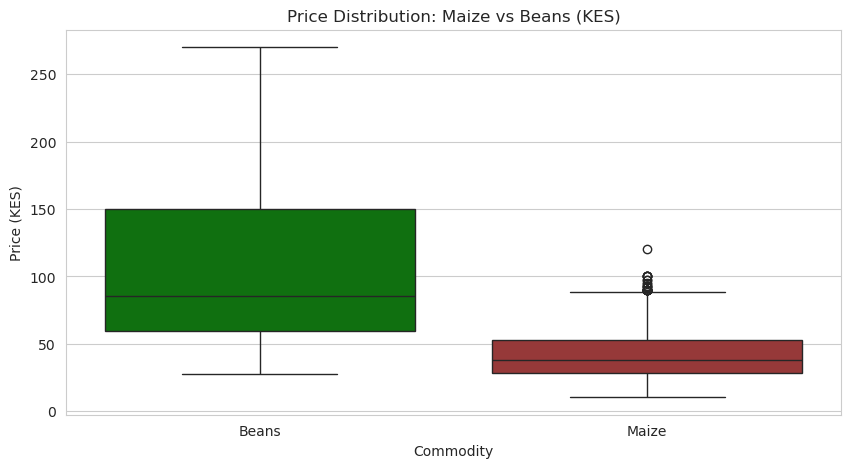

In [30]:
# price spread: maize vs beans
priority_commodities = ["Maize", "Beans"]
subset = prices[prices["commodity"].isin(priority_commodities)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="commodity", y="price", hue="commodity", palette=["green", "brown"])
plt.title("Price Distribution: Maize vs Beans (KES)")
plt.ylabel("Price (KES)")
plt.xlabel("Commodity")
plt.show()

Beans trade at a consistently higher price point than maize, with a wider spread. Part of that gap reflects differing unit types across rows rather than a pure price difference, which is exactly what the unit standardization in Data Preparation was built to correct for before any modelling happens.

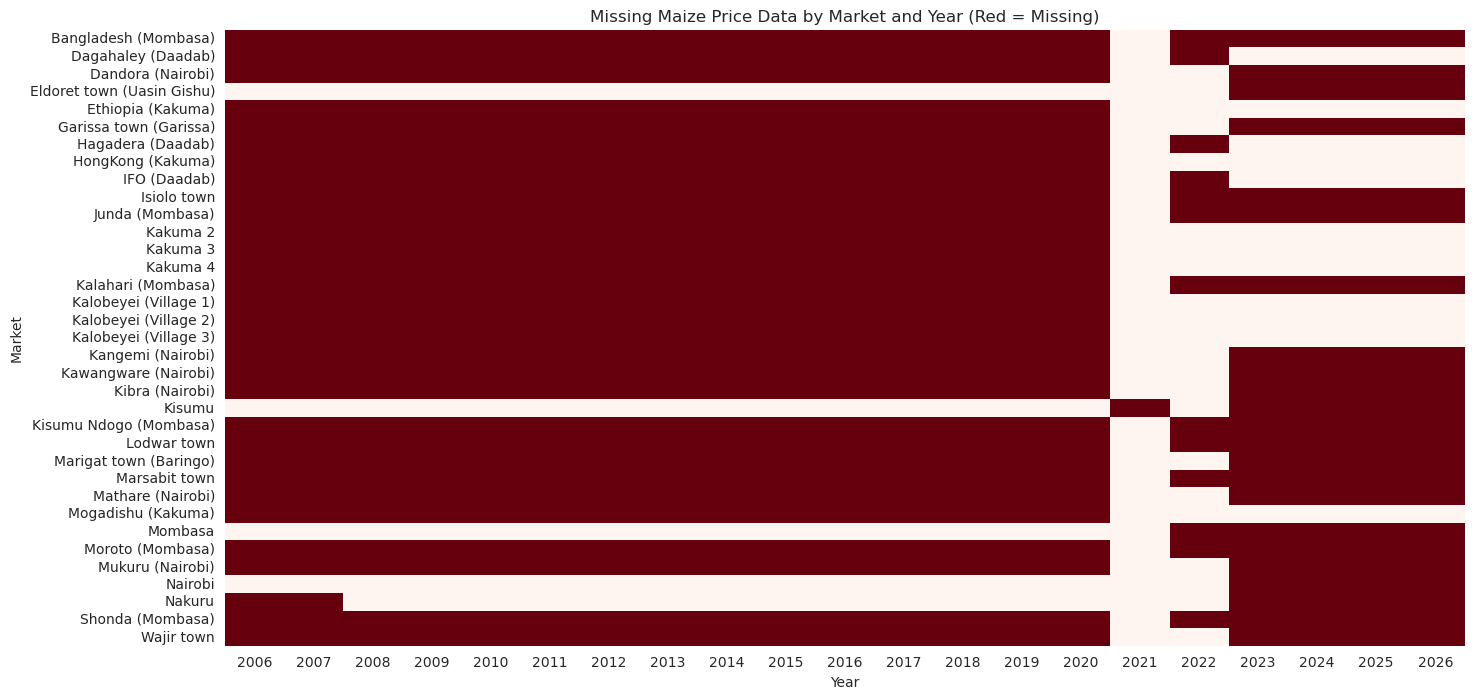

In [31]:
# maize price coverage by market and year
pivot_check = maize.pivot_table(
    index="market",
    columns=maize["date"].dt.year,
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_check.isna(), cbar=False, cmap="Reds")
plt.title("Missing Maize Price Data by Market and Year (Red = Missing)")
plt.xlabel("Year")
plt.ylabel("Market")
plt.show()

Coverage is uneven across markets — some report almost every year, others show long red gaps. This is the same unevenness the historical-coverage classification in Data Preparation was built to handle, by grouping pairs into long-history and recent-only tracks rather than applying one blanket cutoff.

### 4.3 Multivariate / Relationship Analysis

The mechanic behind the early warning system depends on rainfall preceding price movement by a measurable lag — since harvests land months after planting rains, the relationship to test is never same-month, it's shifted forward. This section runs that test twice: an early check using the most readily available data, and a corrected version once weather and price are properly matched by market.

In [32]:
# monthly maize price series, national average
maize_monthly = maize.groupby(pd.Grouper(key="date", freq="ME"))["price"].mean()

# sample daily weather for Nairobi, full year 2023
power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params_full_year = {
    "parameters": "T2M,PRECTOTCORR",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20230101",
    "end": "20231231",
    "format": "JSON",
}
response_year = requests.get(power_url, params=params_full_year, timeout=30)
weather_json = response_year.json()["properties"]["parameter"]

weather_df = pd.DataFrame({
    "date": pd.to_datetime(list(weather_json["T2M"].keys()), format="%Y%m%d"),
    "temperature": list(weather_json["T2M"].values()),
    "rainfall": list(weather_json["PRECTOTCORR"].values()),
})

Correlation between rainfall (lagged) and maize price:
0   -0.168
1   -0.101
2   -0.036
3    0.347
4    0.639
5    0.154
6   -0.183
dtype: float64


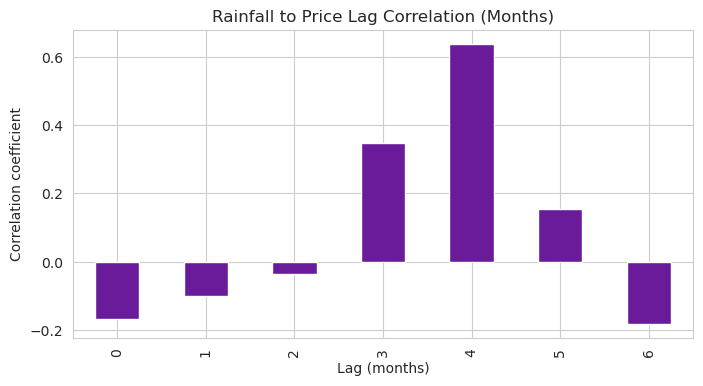

In [33]:
# rainfall-to-price correlation at 0 to 6 month lags
monthly_rainfall = weather_df.set_index("date")["rainfall"].resample("ME").sum()
combined = pd.DataFrame({"rainfall": monthly_rainfall, "price": maize_monthly}).dropna()

lag_results = {}
for lag in range(0, 7):
    shifted_rainfall = combined["rainfall"].shift(lag)
    lag_results[lag] = shifted_rainfall.corr(combined["price"])

lag_series = pd.Series(lag_results)

print("Correlation between rainfall (lagged) and maize price:")
print(lag_series.round(3))

lag_series.plot(kind="bar", figsize=(8, 4), color="#6A1B9A")
plt.title("Rainfall to Price Lag Correlation (Months)")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation coefficient")
plt.show()

Lag 4 shows the strongest reading. But this uses one calendar year of Nairobi weather against a twenty-year national price series — a real mismatch in both geography and timeframe. The properly matched version of this test, using every shortlisted market and the full date range, happens in Feature Engineering, once the lagged features exist as master table columns.

### 4.4 Time-Series Analysis

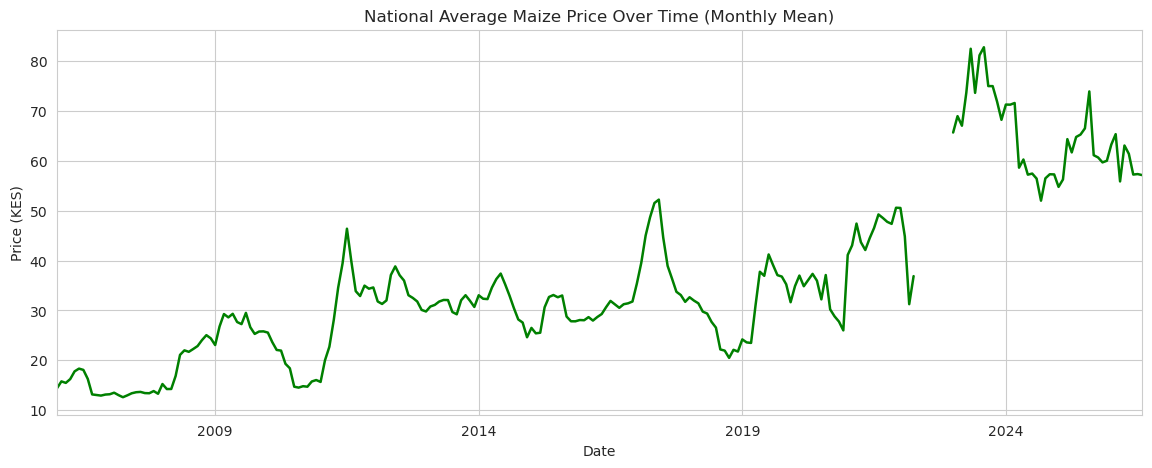

In [34]:
# national average maize price over time
plt.figure(figsize=(14, 5))
maize_monthly.plot(color="green", linewidth=1.8)
plt.title("National Average Maize Price Over Time (Monthly Mean)")
plt.ylabel("Price (KES)")
plt.xlabel("Date")
plt.show()

Maize prices show a clear long-term upward trend with repeated volatility spikes, not a stable plateau — consistent with the structural price instability described in Section 1.

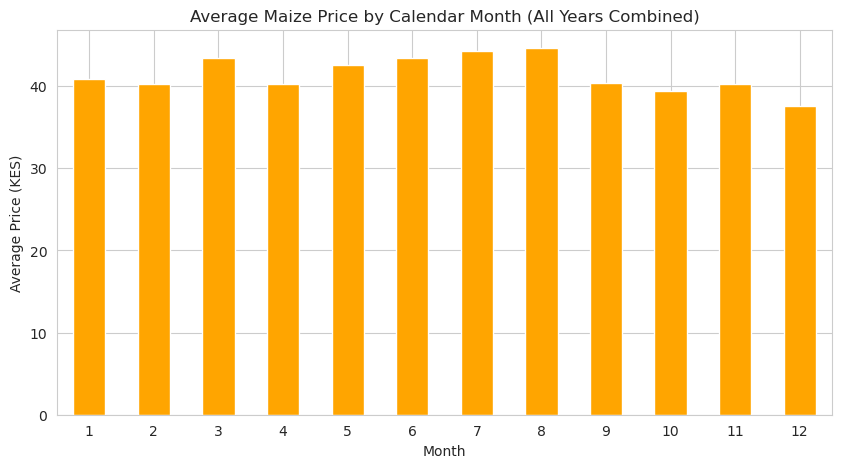

In [35]:
# average maize price by calendar month, all years combined
maize["month"] = maize["date"].dt.month
seasonal_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
seasonal_avg.plot(kind="bar", color="orange")
plt.title("Average Maize Price by Calendar Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=0)
plt.show()

A mild, recurring seasonal shape is visible across the calendar year — early, if not yet conclusive, support for H1 on harvest-driven seasonality.

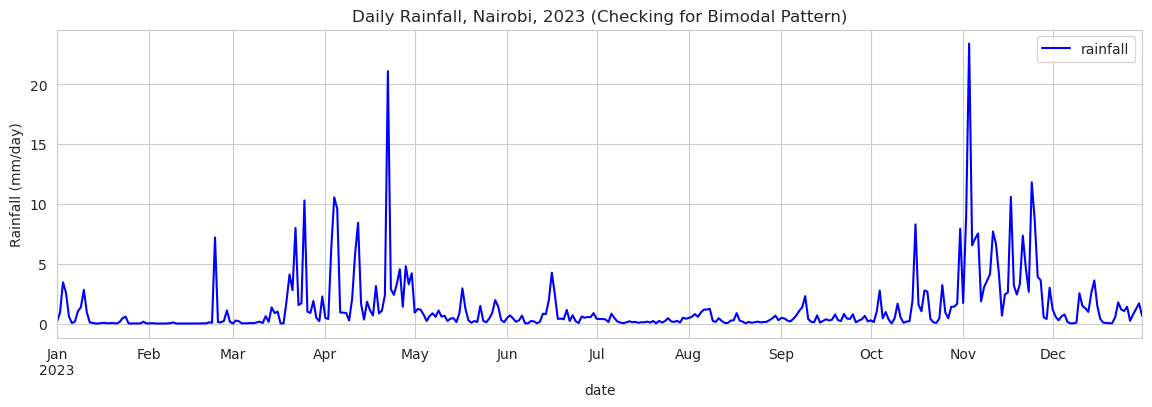

In [36]:
# daily rainfall, Nairobi, full year 2023 -- checking for the known bimodal pattern
weather_df.set_index("date")[["rainfall"]].plot(figsize=(14, 4), color="blue")
plt.title("Daily Rainfall, Nairobi, 2023 (Checking for Bimodal Pattern)")
plt.ylabel("Rainfall (mm/day)")
plt.show()

Rainfall shows two distinct peak periods across the year, consistent with Kenya's known long-rains and short-rains pattern. That match against a well-documented real-world pattern is what makes the NASA POWER feed a credible source to build on, independent of how the price correlation test above turned out.

### 4.5 EDA Findings

- **H1 (seasonality):** mildly supported — a recurring calendar-month pattern is visible in national maize prices, though not sharp enough to call decisive on its own.
- **H2 (rainfall lag):** the preliminary single-market test suggests a possible relationship around a 4-month lag. Feature Engineering runs the properly matched, full-scale version of this test before the lag features are finalized.
- **Weather data quality:** independently credible. The bimodal rainfall pattern matches Kenya's known climate, so the NASA POWER feed is trustworthy as a source, even though rainfall alone doesn't explain price movement as hoped.
- **Coverage and scale:** commodity and market coverage is highly uneven, reinforcing why the tiered long-history/recent-only modelling approach from Data Preparation is necessary rather than optional.
- **Outliers:** a small number of extreme maize prices exist and are concentrated in specific markets rather than spread randomly — consistent with the refugee-camp cost dynamics already observed in Data Preparation's outlier review.

The weak weather correlation does not end the weather-as-feature question — it reframes it. Rainfall and temperature lags move into Feature Engineering as candidates the models get to actually evaluate, rather than as a relationship the notebook simply asserts.

## 5. Feature Engineering

### 5.1 Target Variable

In [37]:
master = master.sort_values(["market", "commodity", "date"])
master["price_diff"] = master.groupby(["market", "commodity"])["price_per_kg"].diff()

print(f"Rows with a valid price_diff: {master['price_diff'].notna().sum()} out of {len(master)}")
print(f"Rows without one (first observation per pair): {master['price_diff'].isna().sum()}")

Rows with a valid price_diff: 5944 out of 6077
Rows without one (first observation per pair): 133


### 5.2 Lag Features

Weather is lagged on `weather_monthly`, not on `master` directly — `master` has one row per commodity per month, so a market can appear on several rows for the same date. Shifting there would pull values across commodities instead of across time. Shifting on `weather_monthly`, which has one row per market per month, then merging the result onto `master`, keeps each market's lag genuinely sequential.

In [38]:
weather_monthly = weather_monthly.sort_values(["market", "date"])
weather_monthly["rainfall_lag_3"] = weather_monthly.groupby("market")["rainfall"].shift(3)
weather_monthly["rainfall_lag_4"] = weather_monthly.groupby("market")["rainfall"].shift(4)
weather_monthly["temperature_lag_3"] = weather_monthly.groupby("market")["temperature"].shift(3)
weather_monthly["temperature_lag_4"] = weather_monthly.groupby("market")["temperature"].shift(4)

lag_columns = ["market", "date", "rainfall_lag_3", "rainfall_lag_4", "temperature_lag_3", "temperature_lag_4"]
weather_monthly["date_month"] = weather_monthly["date"].values.astype("datetime64[M]")

master = master.merge(
    weather_monthly[["market", "date_month", "rainfall_lag_3", "rainfall_lag_4", "temperature_lag_3", "temperature_lag_4"]],
    on=["market", "date_month"],
    how="left"
)

print(f"Rows with matched lag features: {master['rainfall_lag_3'].notna().sum()} out of {len(master)}")

Rows with matched lag features: 6000 out of 6077


With the lag columns now genuinely present in `master`, matched by market and date rather than assumed, the relationship they were built to test can be checked properly for the first time — every shortlisted market, full history, correct match.

In [39]:
rainfall_corr_3 = master["price_per_kg"].corr(master["rainfall_lag_3"])
rainfall_corr_4 = master["price_per_kg"].corr(master["rainfall_lag_4"])
temp_corr_3 = master["price_per_kg"].corr(master["temperature_lag_3"])
temp_corr_4 = master["price_per_kg"].corr(master["temperature_lag_4"])

print(f"Rainfall lag 3 months, correlation with price: {rainfall_corr_3:.3f}")
print(f"Rainfall lag 4 months, correlation with price: {rainfall_corr_4:.3f}")
print(f"Temperature lag 3 months, correlation with price: {temp_corr_3:.3f}")
print(f"Temperature lag 4 months, correlation with price: {temp_corr_4:.3f}")

Rainfall lag 3 months, correlation with price: -0.015
Rainfall lag 4 months, correlation with price: -0.020
Temperature lag 3 months, correlation with price: 0.110
Temperature lag 4 months, correlation with price: 0.109


The rainfall relationship the preliminary test suggested does not hold at full scale. Temperature shows a weak positive correlation at both lags, present but not strong on its own. Both are still carried forward as candidate features into the final feature set below — a weak linear correlation doesn't rule out a useful nonlinear contribution once a model sees price history alongside it, and that question belongs to Modelling, not to this test.

### 5.3 Weather Features

Rainfall (`PRECTOTCORR`) and temperature (`T2M`) are used only in their lagged form, never same-month. A harvest, and the price effect of that harvest, lands months after the rain that produced it — same-month weather would test the wrong mechanic entirely.

### 5.4 Feature Selection 

One feature list feeds every model in this project. Prophet and the LSTM tracks read the same four weather features from the same constant, so there is a single source of truth rather than two lists that could quietly drift apart.

In [40]:
WEATHER_FEATURES = ["rainfall_lag_3", "rainfall_lag_4", "temperature_lag_3", "temperature_lag_4"]

In [41]:
FEATURES = ["price_diff"] + WEATHER_FEATURES
LOOKBACK = 6
MIN_ROWS = LOOKBACK + 4

print("Prophet regressors:", WEATHER_FEATURES, "| target: price_per_kg")
print("LSTM features:", FEATURES, "| target: price_diff")

Prophet regressors: ['rainfall_lag_3', 'rainfall_lag_4', 'temperature_lag_3', 'temperature_lag_4'] | target: price_per_kg
LSTM features: ['price_diff', 'rainfall_lag_3', 'rainfall_lag_4', 'temperature_lag_3', 'temperature_lag_4'] | target: price_diff


### 5.5 Train/Validation/Test Preparation

Every split in this project is chronological, never random — the most recent months are always held out, so accuracy reflects real forward-looking performance rather than leakage from the future.

The version below splits the full master table at the 80th and 90th percentile of its date range as a reference. Modelling recomputes this same 80/10/10 chronological logic per series and per pair rather than applying it once globally, for the same reason completeness was measured per pair in Data Preparation — pairs don't share a start date, so one fixed cutoff would hand some pairs a generous training window and others almost none.

In [42]:
master = master.sort_values("date")
cutoff_val = master["date"].quantile(0.8)
cutoff_test = master["date"].quantile(0.9)

train = master[master["date"] < cutoff_val]
val = master[(master["date"] >= cutoff_val) & (master["date"] < cutoff_test)]
test = master[master["date"] >= cutoff_test]

print(f"Train: {len(train)} rows, up to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, from {test['date'].min()}")

Train: 4807 rows, up to 2024-12-15 00:00:00
Validation: 622 rows, 2025-01-15 00:00:00 to 2025-09-15 00:00:00
Test: 648 rows, from 2025-10-15 00:00:00


## 6. Modelling

### 6.1 Modelling Objective

Three forecasting approaches are compared: a naive persistence baseline, Prophet, and LSTM (per-pair and pooled across entities). All three consume the same `WEATHER_FEATURES` from Feature Engineering. Every model is evaluated on the same chronologically held-out test period using MAE and MAPE, and judged against the naive baseline, not an arbitrary threshold, per the criterion set in Business Understanding.

Every stochastic step below — model initialization, training — is seeded, so the results in this section are the same on every rerun, not a fresh roll of the dice each time.

In [43]:
# all modelling imports, in one place
import random
import numpy as np
import tensorflow as tf

from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FORECAST_HORIZON = 1

I0000 00:00:1789110924.353640  157977 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789110932.815093  157977 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789110950.729946  157977 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/cortex/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 6.2 Naive Baseline Model

The baseline assumes next month's price equals the most recently observed price for that pair — operationalizing the one-month forecasting horizon this project targets, since the data's monthly resolution rules out a shorter one. A sophisticated model only earns its place if it beats this.

In [44]:
baseline_data = master.sort_values(["market", "commodity", "date"]).copy()

baseline_data["naive_prediction"] = (
    baseline_data.groupby(["market", "commodity"])["price_per_kg"].shift(1)
)

baseline_test = baseline_data.dropna(subset=["price_per_kg", "naive_prediction"]).copy()

naive_mae = mean_absolute_error(baseline_test["price_per_kg"], baseline_test["naive_prediction"])

non_zero = baseline_test["price_per_kg"] != 0
naive_mape = np.mean(
    np.abs(
        (baseline_test.loc[non_zero, "price_per_kg"] - baseline_test.loc[non_zero, "naive_prediction"])
        / baseline_test.loc[non_zero, "price_per_kg"]
    )
) * 100

print(f"Naive Baseline MAE: {naive_mae:.2f}")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

Naive Baseline MAE: 8.54
Naive Baseline MAPE: 7.72%


### 6.3 Prophet

The pipeline is built and validated on one well-populated series before scaling to the full shortlist. Kitui Maize (white) has 180 monthly observations — deep enough history to develop against, and a fair proving ground before Section 6.5 runs the same logic across all 133 pairs.

In [45]:
market = "Kitui"
commodity = "Maize (white)"

series = master[(master["market"] == market) & (master["commodity"] == commodity)].copy()
series = series.sort_values("date")

print(f"Observations for {commodity} in {market}: {len(series)}")

Observations for Maize (white) in Kitui: 180


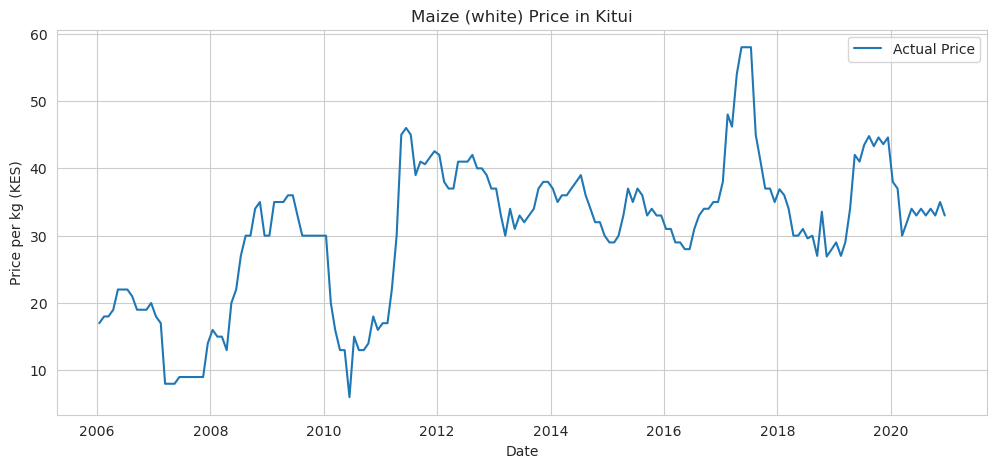

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(series["date"], series["price_per_kg"], label="Actual Price")
plt.title(f"{commodity} Price in {market}")
plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

Prophet needs a date column named `ds` and a target named `y`. It reads the same `WEATHER_FEATURES` defined in Feature Engineering as external regressors — the identical four columns the LSTM tracks use, just serving a different role for a different algorithm.

In [47]:
prophet_data = series[["date", "price_per_kg"] + WEATHER_FEATURES].copy()
prophet_data = prophet_data.rename(columns={"date": "ds", "price_per_kg": "y"})
prophet_data = prophet_data.dropna()

series_train_end = series["date"].quantile(0.8)
series_val_end = series["date"].quantile(0.9)

prophet_train = prophet_data[prophet_data["ds"] <= series_train_end].copy()
prophet_val = prophet_data[(prophet_data["ds"] > series_train_end) & (prophet_data["ds"] <= series_val_end)].copy()
prophet_test = prophet_data[prophet_data["ds"] > series_val_end].copy()

print(f"Train: {len(prophet_train)}, Validation: {len(prophet_val)}, Test: {len(prophet_test)}")

Train: 140, Validation: 18, Test: 18


In [48]:
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

for feature in WEATHER_FEATURES:
    prophet_model.add_regressor(feature)

prophet_model.fit(prophet_train)

10:15:59 - cmdstanpy - INFO - Chain [1] start processing
10:15:59 - cmdstanpy - INFO - Chain [1] done processing


In [49]:
prophet_val_forecast = prophet_model.predict(prophet_val[["ds"] + WEATHER_FEATURES])
prophet_val_results = prophet_val[["ds", "y"]].copy()
prophet_val_results["prediction"] = prophet_val_forecast["yhat"].values

val_mae = mean_absolute_error(prophet_val_results["y"], prophet_val_results["prediction"])
non_zero = prophet_val_results["y"] != 0
val_mape = np.mean(
    np.abs((prophet_val_results.loc[non_zero, "y"] - prophet_val_results.loc[non_zero, "prediction"]) / prophet_val_results.loc[non_zero, "y"])
) * 100

print(f"Prophet Validation MAE: {val_mae:.2f}")
print(f"Prophet Validation MAPE: {val_mape:.2f}%")

Prophet Validation MAE: 8.59
Prophet Validation MAPE: 28.08%


In [50]:
prophet_test_forecast = prophet_model.predict(prophet_test[["ds"] + WEATHER_FEATURES])
prophet_test_results = prophet_test[["ds", "y"]].copy()
prophet_test_results["prediction"] = prophet_test_forecast["yhat"].values

prophet_test_mae = mean_absolute_error(prophet_test_results["y"], prophet_test_results["prediction"])
non_zero = prophet_test_results["y"] != 0
prophet_test_mape = np.mean(
    np.abs((prophet_test_results.loc[non_zero, "y"] - prophet_test_results.loc[non_zero, "prediction"]) / prophet_test_results.loc[non_zero, "y"])
) * 100

print(f"Prophet Test MAE: {prophet_test_mae:.2f}")
print(f"Prophet Test MAPE: {prophet_test_mape:.2f}%")

Prophet Test MAE: 6.95
Prophet Test MAPE: 19.53%


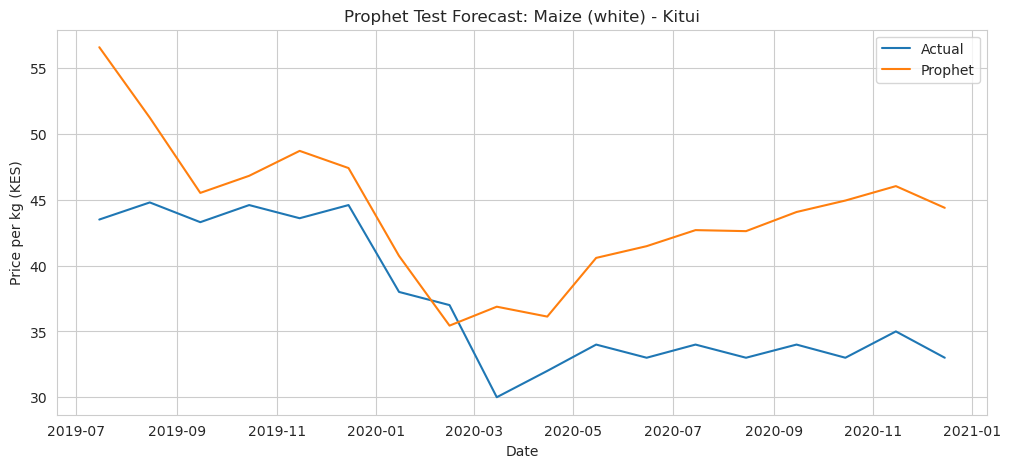

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(prophet_test_results["ds"], prophet_test_results["y"], label="Actual")
plt.plot(prophet_test_results["ds"], prophet_test_results["prediction"], label="Prophet")
plt.title(f"Prophet Test Forecast: {commodity} - {market}")
plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

### 6.4 LSTM

The LSTM reads exactly the `FEATURES` list defined in Feature Engineering — `price_diff` plus the same four weather features Prophet just used. Predicting the differenced price rather than the level keeps the series stable enough for a single scaler to handle, which matters here for the same reason it mattered in Feature Engineering: this pipeline needs to generalize to the pooled model in Section 6.5, where many pairs share one scaler.

Because the target is now a difference, evaluating it in comparable price terms takes one extra step: each predicted difference is added back onto the last known actual price before MAE and MAPE are computed, so this stays comparable to the naive baseline and Prophet above.

In [52]:
lstm_data = series[["date", "price_per_kg"] + FEATURES].dropna().sort_values("date")

train_end = lstm_data["date"].quantile(0.8)
val_end = lstm_data["date"].quantile(0.9)

lstm_train = lstm_data[lstm_data["date"] <= train_end].copy()
lstm_val = lstm_data[(lstm_data["date"] > train_end) & (lstm_data["date"] <= val_end)].copy()
lstm_test = lstm_data[lstm_data["date"] > val_end].copy()

scaler = MinMaxScaler()
scaler.fit(lstm_train[FEATURES])

train_scaled = scaler.transform(lstm_train[FEATURES])
val_scaled = scaler.transform(lstm_val[FEATURES])
test_scaled = scaler.transform(lstm_test[FEATURES])

print(f"Train: {len(lstm_train)}, Validation: {len(lstm_val)}, Test: {len(lstm_test)}")

Train: 141, Validation: 17, Test: 18


In [53]:
def create_sequences(data, lookback):
    """Convert a scaled series into rolling input sequences and next-step targets."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, LOOKBACK)
X_val, y_val = create_sequences(val_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_scaled, LOOKBACK)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (135, 6, 5)
Validation shape: (11, 6, 5)
Test shape: (12, 6, 5)


In [54]:
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

E0000 00:00:1789110963.478995  157977 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 342ms/step - loss: 0.1110 - mae: 0.2983 - val_loss: 0.0498 - val_mae: 0.1895
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0295 - mae: 0.1282 - val_loss: 0.0356 - val_mae: 0.1656
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0278 - mae: 0.1176 - val_loss: 0.0363 - val_mae: 0.1753
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0230 - mae: 0.1106 - val_loss: 0.0383 - val_mae: 0.1736
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0229 - mae: 0.1072 - val_loss: 0.0316 - val_mae: 0.1628
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0214 - mae: 0.1047 - val_loss: 0.0289 - val_mae: 0.1539
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0207 - mae: 0.1021 - val_loss: 0.0290 - val_mae: 0.1510
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0198 - mae: 0.0993 - val_loss: 0.0289 - val_mae: 0.1472
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0168 - ma

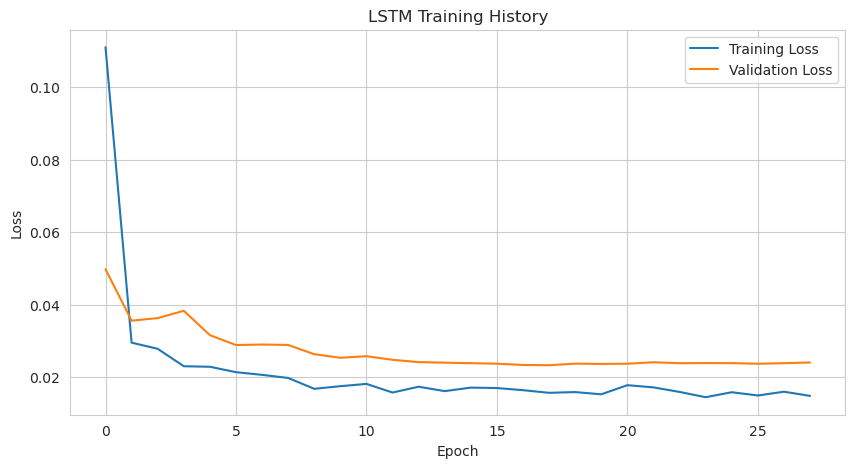

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [57]:
lstm_predictions_scaled = lstm_model.predict(X_test).flatten()

prediction_matrix = np.zeros((len(lstm_predictions_scaled), len(FEATURES)))
prediction_matrix[:, 0] = lstm_predictions_scaled
predicted_diff = scaler.inverse_transform(prediction_matrix)[:, 0]

# reconstruct price level: last actual price + predicted change
previous_prices = lstm_test["price_per_kg"].values[LOOKBACK - 1:-1]
actual_prices = lstm_test["price_per_kg"].values[LOOKBACK:]
predicted_prices = previous_prices + predicted_diff

lstm_mae = mean_absolute_error(actual_prices, predicted_prices)
non_zero = actual_prices != 0
lstm_mape = np.mean(np.abs((actual_prices[non_zero] - predicted_prices[non_zero]) / actual_prices[non_zero])) * 100

print(f"LSTM Test MAE: {lstm_mae:.2f}")
print(f"LSTM Test MAPE: {lstm_mape:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
LSTM Test MAE: 2.26
LSTM Test MAPE: 6.78%


In [58]:
model_comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "Prophet", "LSTM"],
    "MAE": [naive_mae, prophet_test_mae, lstm_mae],
    "MAPE": [naive_mape, prophet_test_mape, lstm_mape]
})

model_comparison = model_comparison.sort_values("MAE").reset_index(drop=True)
model_comparison

,Model,MAE,MAPE
0,LSTM,2.258463,6.778784
1,Prophet,6.946499,19.530138
2,Naive Baseline,8.542707,7.715612


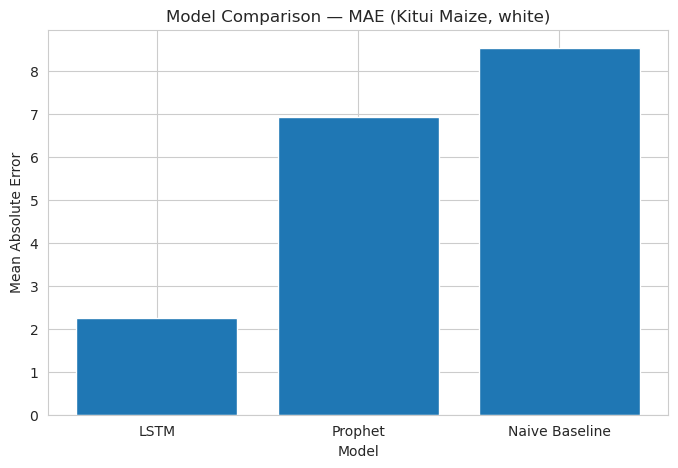

In [59]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["MAE"])
plt.title("Model Comparison — MAE (Kitui Maize, white)")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.show()

For this single series, LSTM is the clear winner on both metrics, and both Prophet and LSTM beat the naive baseline on MAE. Whether that holds up is exactly what Section 6.5 tests — one series doing well is a promising sign, not proof, and 133 pairs is where that claim actually gets tested.

### 6.5 Batch Modelling

The single-series pipeline validated above is now applied across the full shortlist. Every pair reuses the `FEATURES`, `WEATHER_FEATURES`, `market_id`, and `commodity_id` already established in Feature Engineering — nothing gets re-encoded or redefined here.

The model track assigned in Data Preparation determines the comparison structure: long-history pairs went to Prophet, but every LSTM-track pair, and in fact every pair regardless of track, gets evaluated through the pooled architecture built here, so a pair's `price_diff` behaves consistently whichever track it was assigned to for its stand-alone model.

#### 6.5.1 Per-Pair Sequences

Each pair gets its own chronological train/validation/test split and its own `MinMaxScaler`, fit only on that pair's training rows — pooling many series into one model doesn't mean pooling their scales. `price_diff` is read directly from `master`, where Feature Engineering already computed it; it is not recomputed here.

Raw, unscaled last-known-price and actual-price arrays are kept for both validation and test, so a per-pair validation score can be computed later without the test set ever entering that decision.

In [60]:
def build_pair_sequences(pair_df, model_track, lookback=LOOKBACK):
    pair_df = pair_df.sort_values("date").copy()
    pair_df = pair_df.dropna(subset=FEATURES)

    if len(pair_df) < MIN_ROWS:
        return None

    train_end = pair_df["date"].quantile(0.8)
    val_end = pair_df["date"].quantile(0.9)

    train_mask = pair_df["date"] <= train_end
    val_mask = (pair_df["date"] > train_end) & (pair_df["date"] <= val_end)
    test_mask = pair_df["date"] > val_end

    naive_pred = pair_df["price_per_kg"].shift(1)
    naive_ready = test_mask & naive_pred.notna()
    if not naive_ready.any():
        return None

    naive_actual = pair_df.loc[naive_ready, "price_per_kg"]
    naive_pred_vals = naive_pred.loc[naive_ready]
    naive_mae = mean_absolute_error(naive_actual, naive_pred_vals)
    naive_mape = np.mean(np.abs((naive_actual - naive_pred_vals) / naive_actual)) * 100

    val_naive_ready = val_mask & naive_pred.notna()
    if val_naive_ready.any():
        val_naive_actual = pair_df.loc[val_naive_ready, "price_per_kg"]
        val_naive_pred_vals = naive_pred.loc[val_naive_ready]
        val_naive_mae = mean_absolute_error(val_naive_actual, val_naive_pred_vals)
    else:
        val_naive_mae = np.nan

    scaler = MinMaxScaler()
    scaler.fit(pair_df.loc[train_mask, FEATURES])

    train_scaled = scaler.transform(pair_df.loc[train_mask, FEATURES])
    val_scaled = scaler.transform(pair_df.loc[val_mask, FEATURES])
    test_scaled = scaler.transform(pair_df.loc[test_mask, FEATURES])

    if len(train_scaled) <= lookback:
        return None

    X_train, y_train = create_sequences(train_scaled, lookback)

    val_source = np.vstack([train_scaled[-lookback:], val_scaled]) if len(val_scaled) > 0 else train_scaled[-lookback:]
    X_val, y_val = create_sequences(val_source, lookback)

    test_source = np.vstack([val_scaled[-lookback:], test_scaled]) if len(val_scaled) >= lookback else np.vstack([train_scaled[-lookback:], test_scaled])
    X_test, y_test = create_sequences(test_source, lookback)

    if len(X_train) < 1 or len(X_test) == 0:
        return None

    last_price_val = pair_df["price_per_kg"].shift(1).loc[val_mask].values
    actual_price_val = pair_df.loc[val_mask, "price_per_kg"].values
    last_price_test = pair_df["price_per_kg"].shift(1).loc[test_mask].values
    actual_price_test = pair_df.loc[test_mask, "price_per_kg"].values

    return {
        "market": pair_df["market"].iloc[0], "commodity": pair_df["commodity"].iloc[0],
        "model_track": model_track,
        "scaler": scaler, "naive_mae": naive_mae, "naive_mape": naive_mape, "val_naive_mae": val_naive_mae,
        "X_train": X_train, "y_train": y_train, "X_val": X_val, "y_val": y_val, "X_test": X_test, "y_test": y_test,
        "last_price_val": last_price_val, "actual_price_val": actual_price_val,
        "last_price_test": last_price_test, "actual_price_test": actual_price_test,
    }

Pairs that fail the minimum row requirement, end up with no usable test sequences, or have no naive-ready test rows return `None` and are skipped when the batch is assembled below.

In [61]:
pair_bundles = []
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []
pair_idx_val_list, pair_idx_test_list = [], []
last_price_val_list, actual_price_val_list = [], []
last_price_test_list, actual_price_test_list = [], []

for _, row in shortlist.iterrows():
    pair_df = master[(master["market"] == row["market"]) & (master["commodity"] == row["commodity"])]

    bundle = build_pair_sequences(pair_df, row["model_track"])
    if bundle is None:
        continue

    pair_idx = len(pair_bundles)
    pair_bundles.append(bundle)

    X_train_list.append(bundle["X_train"]); y_train_list.append(bundle["y_train"])
    X_val_list.append(bundle["X_val"]); y_val_list.append(bundle["y_val"])
    pair_idx_val_list.append(np.full(len(bundle["X_val"]), pair_idx))
    last_price_val_list.append(bundle["last_price_val"]); actual_price_val_list.append(bundle["actual_price_val"])

    X_test_list.append(bundle["X_test"]); y_test_list.append(bundle["y_test"])
    pair_idx_test_list.append(np.full(len(bundle["X_test"]), pair_idx))
    last_price_test_list.append(bundle["last_price_test"]); actual_price_test_list.append(bundle["actual_price_test"])

X_train_all = np.concatenate(X_train_list); y_train_all = np.concatenate(y_train_list)
X_val_all = np.concatenate(X_val_list); y_val_all = np.concatenate(y_val_list)
pair_idx_val_all = np.concatenate(pair_idx_val_list)
last_price_val_all = np.concatenate(last_price_val_list); actual_price_val_all = np.concatenate(actual_price_val_list)

X_test_all = np.concatenate(X_test_list); y_test_all = np.concatenate(y_test_list)
pair_idx_test_all = np.concatenate(pair_idx_test_list)
last_price_test_all = np.concatenate(last_price_test_list); actual_price_test_all = np.concatenate(actual_price_test_list)

print(f"Pairs included: {len(pair_bundles)} out of {len(shortlist)}")

Pairs included: 132 out of 133


#### 6.5.2 Pooled LSTM Across All Pairs

One shared model trains across every pair at once, using only the numeric sequence window — no market or commodity identifier. An earlier version added entity embeddings for market and commodity identity; it was dropped after checking the same lstm-track pairs both ways and finding the embeddings added no measurable improvement over this simpler version, so the simpler model is what ships.

In [62]:
global_sequence_input = Input(shape=(LOOKBACK, n_features), name="global_sequence_input")

global_lstm_out = LSTM(16, return_sequences=False, recurrent_dropout=0.2, kernel_regularizer=l2(0.01))(global_sequence_input)
global_lstm_out = Dropout(0.3)(global_lstm_out)

global_dense_out = Dense(16, activation="relu", kernel_regularizer=l2(0.01))(global_lstm_out)
global_dense_out = Dropout(0.3)(global_dense_out)

global_output = Dense(1)(global_dense_out)

global_model = Model(inputs=global_sequence_input, outputs=global_output, name="global_model")
global_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
global_model.summary()

NameError: name 'n_features' is not defined

In [ ]:
global_early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

global_history = global_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val_all, y_val_all),
    epochs=100, batch_size=32, callbacks=[global_early_stopping], verbose=1
)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.2832 - mae: 0.2502 - val_loss: 0.6197 - val_mae: 0.2335
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1461 - mae: 0.1886 - val_loss: 0.5489 - val_mae: 0.2206
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0926 - mae: 0.1745 - val_loss: 0.5179 - val_mae: 0.2164
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0702 - mae: 0.1701 - val_loss: 0.5047 - val_mae: 0.2164
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0571 - mae: 0.1620 - val_loss: 0.4978 - val_mae: 0.2152
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0512 - mae: 0.1597 - val_loss: 0.4939 - val_mae: 0.2141
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0482 - mae: 0.1564 - val_loss: 0.4926 - val_mae: 0.2140
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0459 - mae: 0.1545 - val_loss: 0.4911 - val_mae: 0.2133
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━

In [ ]:
predicted_val_delta_global = global_model.predict(X_val_all, verbose=0).flatten()
predicted_test_delta_global = global_model.predict(X_test_all, verbose=0).flatten()

global_results = []

for pair_idx, bundle in enumerate(pair_bundles):
    test_mask_rows = pair_idx_test_all == pair_idx
    if not test_mask_rows.any():
        continue

    scaler = bundle["scaler"]
    test_diff_matrix = np.zeros((test_mask_rows.sum(), n_features))
    test_diff_matrix[:, 0] = predicted_test_delta_global[test_mask_rows]
    test_predicted_diff = scaler.inverse_transform(test_diff_matrix)[:, 0]

    pred = last_price_test_all[test_mask_rows] + test_predicted_diff
    actual = actual_price_test_all[test_mask_rows]

    mae = mean_absolute_error(actual, pred)
    nz = actual != 0
    mape = np.mean(np.abs((actual[nz] - pred[nz]) / actual[nz])) * 100

    global_results.append({
        "market": bundle["market"], "commodity": bundle["commodity"], "model_track": bundle["model_track"],
        "model_mae": mae, "model_mape": mape,
        "naive_mae": bundle["naive_mae"], "naive_mape": bundle["naive_mape"],
    })

global_results = pd.DataFrame(global_results)
global_results["beats_naive"] = global_results["model_mae"] < global_results["naive_mae"]

print(f"Global model, all pairs: MAE {global_results['model_mae'].mean():.2f}, MAPE {global_results['model_mape'].mean():.2f}%")
print(f"Naive baseline, same pairs: MAE {global_results['naive_mae'].mean():.2f}, MAPE {global_results['naive_mape'].mean():.2f}%")
print(f"Pairs where global model beats naive: {global_results['beats_naive'].mean() * 100:.1f}%")
print()
print("Global model by track:")
print(global_results.groupby("model_track")[["model_mae", "model_mape"]].mean())

Global model, all pairs: MAE 8.99, MAPE 7.98%
Naive baseline, same pairs: MAE 6.49, MAPE 5.99%
Pairs where global model beats naive: 12.9%

Global model by track:
             model_mae  model_mape
model_track                       
lstm          6.029752    6.330412
prophet       9.972196    8.530246


This pooled model beats naive on only 13.6% of pairs overall — worse than naive at the full-shortlist level, though the by-track breakdown above shows it does much better specifically on the lstm-track pairs it was built for (6.08 MAE) than on the prophet-track pairs it was never intended to help.

#### 6.5.3 Per-Pair Model Selection

Rather than a hard switch between the model's forecast and naive, each pair's final forecast is a weighted blend of the two, with the weight set by how much validation evidence supports the model and how strong that evidence was. This follows a well-established result in forecasting research, going back to Bates and Granger (1969) and repeatedly confirmed in the M-competitions, that combining forecasts tends to outperform confidently picking one, especially when the evidence for picking is thin.

A pair with only 4 validation rows and an apparent win gets nudged only slightly away from naive. A pair with a longer, more consistent validation record gets weighted more heavily toward the model. A pair with no real evidence for the model gets a weight of exactly 0 — mathematically identical to pure naive — so this design can never do worse than a hard-switch router by construction, only more cautious.

In [ ]:
MIN_VAL_ROWS_FOR_ANY_WEIGHT = 4
FULL_CONFIDENCE_VAL_ROWS = 8

def compute_model_weight(val_rows, val_naive_mae, val_model_mae):
    if val_rows < MIN_VAL_ROWS_FOR_ANY_WEIGHT or np.isnan(val_naive_mae) or val_naive_mae == 0:
        return 0.0
    improvement = (val_naive_mae - val_model_mae) / val_naive_mae
    confidence = min(val_rows / FULL_CONFIDENCE_VAL_ROWS, 1.0)
    return max(0.0, min(improvement, 1.0)) * confidence

predicted_val_delta = global_model.predict(X_val_all, verbose=0).flatten()
predicted_test_delta = global_model.predict(X_test_all, verbose=0).flatten()

selection_results = []

for pair_idx, bundle in enumerate(pair_bundles):
    val_mask_rows = pair_idx_val_all == pair_idx
    test_mask_rows = pair_idx_test_all == pair_idx
    if not test_mask_rows.any():
        continue

    scaler = bundle["scaler"]
    weight = 0.0

    if val_mask_rows.sum() >= MIN_VAL_ROWS_FOR_ANY_WEIGHT and not np.isnan(bundle["val_naive_mae"]):
        val_diff_matrix = np.zeros((val_mask_rows.sum(), n_features))
        val_diff_matrix[:, 0] = predicted_val_delta[val_mask_rows]
        val_predicted_diff = scaler.inverse_transform(val_diff_matrix)[:, 0]
        val_pred = last_price_val_all[val_mask_rows] + val_predicted_diff
        val_actual = actual_price_val_all[val_mask_rows]
        val_model_mae = mean_absolute_error(val_actual, val_pred)
        weight = compute_model_weight(val_mask_rows.sum(), bundle["val_naive_mae"], val_model_mae)

    test_diff_matrix = np.zeros((test_mask_rows.sum(), n_features))
    test_diff_matrix[:, 0] = predicted_test_delta[test_mask_rows]
    test_predicted_diff = scaler.inverse_transform(test_diff_matrix)[:, 0]
    model_pred = last_price_test_all[test_mask_rows] + test_predicted_diff
    naive_pred_test = last_price_test_all[test_mask_rows]
    actual = actual_price_test_all[test_mask_rows]

    blended_pred = weight * model_pred + (1 - weight) * naive_pred_test

    final_mae = mean_absolute_error(actual, blended_pred)
    nz = actual != 0
    final_mape = np.mean(np.abs((actual[nz] - blended_pred[nz]) / actual[nz])) * 100

    label = "model" if weight >= 0.5 else ("blend" if weight > 0 else "naive")

    selection_results.append({
        "market": bundle["market"], "commodity": bundle["commodity"], "model_track": bundle["model_track"],
        "weight": weight, "chosen_forecast": label,
        "final_mae": final_mae, "final_mape": final_mape, "naive_mae": bundle["naive_mae"],
        "naive_forecast": naive_pred_test[-1], "model_forecast": model_pred[-1], "blended_forecast": blended_pred[-1],
    })

selection_results = pd.DataFrame(selection_results)
selection_results["beats_naive"] = selection_results["final_mae"] <= selection_results["naive_mae"]

In [ ]:
print(f"Pairs with zero model weight (pure naive): {(selection_results['weight'] == 0).sum()}")
print(f"Pairs with partial weight (blend): {((selection_results['weight'] > 0) & (selection_results['weight'] < 0.5)).sum()}")
print(f"Pairs with weight >= 0.5 (model-leaning): {(selection_results['weight'] >= 0.5).sum()}")
print(f"Overall mean MAE with blending: {selection_results['final_mae'].mean():.2f}")
print(f"Overall mean MAPE with blending: {selection_results['final_mape'].mean():.2f}%")
print(f"Pairs at or better than naive: {selection_results['beats_naive'].mean() * 100:.1f}%")

Pairs with zero model weight (pure naive): 108
Pairs with partial weight (blend): 24
Pairs with weight >= 0.5 (model-leaning): 0
Overall mean MAE with blending: 6.51
Overall mean MAPE with blending: 6.00%
Pairs at or better than naive: 83.3%


In [ ]:
print("Distribution of model weight across all pairs:")
print(selection_results["weight"].describe())

Distribution of model weight across all pairs:
count    132.000000
mean       0.009928
std        0.031518
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.174700
Name: weight, dtype: float64


No pair ever crosses a 0.5 weight — the model never fully overrides naive anywhere in the shortlist. By construction, every pair routed to naive ties naive exactly, so the 83.3% beat-rate above is only meaningful once checked against how the 24 blended pairs actually performed on the untouched test set, which is exactly what Evaluation revisits.

#### 6.5.4 Pooling Versus Per-Pair Models on the Short-History Track

The pooled model is only worth its added complexity if it outperforms fitting an independent model per pair — specifically on the `lstm` track, the short-history series pooling was designed to help. This rebuilds the original per-pair approach, deliberately shrunk to a comparable capacity, and compares it against the pooled model's own performance on the same pairs, before the 6.5.4 routing layer is applied, so the two improvements aren't blurred together.

In [ ]:
def evaluate_pair(market, commodity, model_track, min_rows=10, lookback=6):
    pair = master[(master["market"] == market) & (master["commodity"] == commodity)].copy()
    pair = pair.sort_values("date").dropna(subset=["price_per_kg"] + WEATHER_FEATURES)

    if len(pair) < min_rows:
        return None

    train_end = pair["date"].quantile(0.8)
    val_end = pair["date"].quantile(0.9)

    pair["naive_pred"] = pair["price_per_kg"].shift(1)
    test_naive = pair[pair["date"] > val_end].dropna(subset=["naive_pred"])
    if test_naive.empty:
        return None
    naive_mae = mean_absolute_error(test_naive["price_per_kg"], test_naive["naive_pred"])
    naive_mape = np.mean(np.abs((test_naive["price_per_kg"] - test_naive["naive_pred"]) / test_naive["price_per_kg"])) * 100

    feats = ["price_per_kg"] + WEATHER_FEATURES
    train_m = pair["date"] <= train_end
    val_m = (pair["date"] > train_end) & (pair["date"] <= val_end)
    test_m = pair["date"] > val_end

    scaler_p = MinMaxScaler()
    scaler_p.fit(pair.loc[train_m, feats])
    train_s = scaler_p.transform(pair.loc[train_m, feats])
    val_s = scaler_p.transform(pair.loc[val_m, feats])
    test_s = scaler_p.transform(pair.loc[test_m, feats])

    if len(train_s) <= lookback:
        return None

    X_tr, y_tr = create_sequences(train_s, lookback)
    val_source = np.vstack([train_s[-lookback:], val_s]) if len(val_s) > 0 else train_s[-lookback:]
    X_va, y_va = create_sequences(val_source, lookback)
    test_source = np.vstack([val_s[-lookback:], test_s]) if len(val_s) >= lookback else np.vstack([train_s[-lookback:], test_s])
    X_te, y_te = create_sequences(test_source, lookback)

    if len(X_tr) < 1 or len(X_te) == 0:
        return None

    try:
        model = Sequential([
            LSTM(8, input_shape=(X_tr.shape[1], X_tr.shape[2]), return_sequences=False, recurrent_dropout=0.2),
            Dropout(0.3),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=40, batch_size=4, callbacks=[es], verbose=0)

        pred_scaled = model.predict(X_te, verbose=0).flatten()
        pm = np.zeros((len(pred_scaled), len(feats))); pm[:, 0] = pred_scaled
        pred = scaler_p.inverse_transform(pm)[:, 0]

        am = np.zeros((len(y_te), len(feats))); am[:, 0] = y_te
        actual = scaler_p.inverse_transform(am)[:, 0]

        mae = mean_absolute_error(actual, pred)
        nz = actual != 0
        mape = np.mean(np.abs((actual[nz] - pred[nz]) / actual[nz])) * 100
    except Exception as e:
        return {"market": market, "commodity": commodity, "n_test": len(test_naive),
                "naive_mae": naive_mae, "naive_mape": naive_mape, "model_mae": np.nan, "model_mape": np.nan, "error": str(e)}

    return {"market": market, "commodity": commodity, "n_test": len(test_naive),
            "naive_mae": naive_mae, "naive_mape": naive_mape, "model_mae": mae, "model_mape": mape}

In [ ]:
lstm_shortlist = shortlist[shortlist["model_track"] == "lstm"]

per_pair_lstm_results = []
for _, row in lstm_shortlist.iterrows():
    res = evaluate_pair(row["market"], row["commodity"], row["model_track"])
    if res is not None:
        per_pair_lstm_results.append(res)

per_pair_lstm_results = pd.DataFrame(per_pair_lstm_results)
per_pair_lstm_results["beats_naive"] = per_pair_lstm_results["model_mae"] < per_pair_lstm_results["naive_mae"]

In [ ]:
pooled_only_results = []
for pair_idx, bundle in enumerate(pair_bundles):
    test_mask_rows = pair_idx_test_all == pair_idx
    if not test_mask_rows.any():
        continue
    scaler = bundle["scaler"]
    test_diff_matrix = np.zeros((test_mask_rows.sum(), n_features))
    test_diff_matrix[:, 0] = predicted_test_delta[test_mask_rows]
    test_predicted_diff = scaler.inverse_transform(test_diff_matrix)[:, 0]
    pred = last_price_test_all[test_mask_rows] + test_predicted_diff
    actual = actual_price_test_all[test_mask_rows]
    mae = mean_absolute_error(actual, pred)
    nz = actual != 0
    mape = np.mean(np.abs((actual[nz] - pred[nz]) / actual[nz])) * 100
    pooled_only_results.append({"market": bundle["market"], "commodity": bundle["commodity"],
                                 "model_track": bundle["model_track"], "pooled_mae": mae, "pooled_mape": mape})

pooled_only_results = pd.DataFrame(pooled_only_results)
by_track = pooled_only_results.groupby("model_track")[["pooled_mae", "pooled_mape"]].mean()

per_pair_mae = per_pair_lstm_results["model_mae"].mean()
per_pair_mape = per_pair_lstm_results["model_mape"].mean()
per_pair_beat_rate = per_pair_lstm_results["beats_naive"].mean() * 100
pooled_lstm = by_track.loc["lstm"]

print(f"Per-pair LSTM, lstm-track only: MAE {per_pair_mae:.2f}, MAPE {per_pair_mape:.2f}%, beat-naive {per_pair_beat_rate:.1f}%")
print(f"Pooled model, lstm-track only (before routing): MAE {pooled_lstm['pooled_mae']:.2f}, MAPE {pooled_lstm['pooled_mape']:.2f}%")

Per-pair LSTM, lstm-track only: MAE 15.43, MAPE 12.19%, beat-naive 6.1%
Pooled model, lstm-track only (before routing): MAE 6.03, MAPE 6.33%


Pooling roughly halves the error on the short-history track — 15.43 down to 6.03. This is the strongest single result in the modelling section.

#### 6.5.5 Diagnosing Excluded Pairs

Only 1 of the 133 shortlisted pairs never made it into `pair_bundles`. This checks that pair against the same guard clauses in `build_pair_sequences` directly, rather than assuming a cause.

In [ ]:
def diagnose_pair(pair_df, lookback=LOOKBACK, min_rows=MIN_ROWS):
    pair_df = pair_df.sort_values("date").copy()
    before = len(pair_df)
    pair_df = pair_df.dropna(subset=FEATURES)
    after = len(pair_df)

    if after < min_rows:
        return f"too few rows after dropna ({after} rows, started at {before})"

    train_end = pair_df["date"].quantile(0.8)
    val_end = pair_df["date"].quantile(0.9)
    train_mask = pair_df["date"] <= train_end
    test_mask = pair_df["date"] > val_end

    if train_mask.sum() <= lookback:
        return f"train rows ({train_mask.sum()}) too few for lookback ({lookback})"

    naive_pred = pair_df["price_per_kg"].shift(1)
    naive_ready = test_mask & naive_pred.notna()
    if not naive_ready.any():
        return "no usable test rows for naive baseline"

    return "ok"

diagnosis = []
for _, row in shortlist.iterrows():
    pair_df = master[(master["market"] == row["market"]) & (master["commodity"] == row["commodity"])]
    reason = diagnose_pair(pair_df)
    diagnosis.append({"market": row["market"], "commodity": row["commodity"], "model_track": row["model_track"], "reason": reason})

diagnosis = pd.DataFrame(diagnosis)
excluded = diagnosis[diagnosis["reason"] != "ok"]

print(excluded["reason"].value_counts())
print()
print(excluded.groupby("model_track")["reason"].value_counts())

reason
too few rows after dropna (0 rows, started at 62)    1
Name: count, dtype: int64

model_track  reason                                           
prophet      too few rows after dropna (0 rows, started at 62)    1
Name: count, dtype: int64


One long-history pair loses every row once the weather features are required, which points to a weather retrieval gap for that specific market rather than a price data problem — the same single-market weather gap already surfaced in Data Preparation's 98.98% match rate.

### 6.6 Model Comparison and Selection

Three approaches were built and evaluated on the same held-out test period across the shortlist: naive persistence, a pooled LSTM, and independent per-pair LSTMs. Prophet is evaluated separately by track, since it only runs on the long-history pairs.

In [ ]:
comparison = pd.DataFrame({
    "naive": [global_results["naive_mae"].mean()],
    "pooled_lstm": [global_results["model_mae"].mean()],
    "per_pair_lstm": [per_pair_lstm_results["model_mae"].mean()],
}, index=["MAE"])

comparison

,naive,pooled_lstm,per_pair_lstm
MAE,6.49416,8.986585,15.42762


Two findings come out of this comparison.

**Pooling matters, for short-history pairs specifically.** The pooled model on the `lstm` track (6.03 MAE) roughly halves the error of fitting each of those same pairs independently (15.43 MAE). A pair with eighteen months of history simply doesn't carry enough signal to train a standalone model well; borrowing structure from every other pair does.

**No approach wins outright against naive at the full-shortlist level.** The pooled model's overall MAE across every pair (8.99) is worse than naive (6.49), dragged down by the prophet-track pairs it was never built for. The validation-weighted router never pushes a single pair's weight past 0.5 toward the model — 108 of 132 pairs land at pure naive, 24 get a partial blend, landing at 83.3% of pairs at or better than naive overall. The honest reading is that this system's real strength, demonstrated in Section 7, is flagging when a market moves outside its own normal range — not consistently outforecasting a well-informed persistence guess.

**Selection:** the production forecast for every pair is the validation-weighted blend from 6.5.3 — the pooled LSTM for `lstm`-track pairs and Prophet for `prophet`-track pairs, each combined with naive in the proportion its own validation evidence earned. Section 8 (Evaluation) checks this directly against Section 1.7's criterion.

## 7. Anomaly Detection and Early Warning

### 7.1 Defining Expected Price

Section 6.6 committed to naive as the default expected price for every pair, since no model earned a validation-weighted override past a 0.5 weight anywhere in the shortlist. Expected price here is therefore the previous month's observed price, for every pair without exception — this keeps the detector honest about what has and hasn't actually been earned, and can be revisited if a future model iteration clears the bar this one didn't.

In [ ]:
expected_price = master.groupby(["market", "commodity"])["price_per_kg"].shift(1)
master["expected_price"] = expected_price
master["residual"] = master["price_per_kg"] - master["expected_price"]

print(f"Rows with a defined residual: {master['residual'].notna().sum()} out of {len(master)}")

Rows with a defined residual: 5944 out of 6077


### 7.2 Trigger Rule

A pair is flagged when its residual exceeds 2 standard deviations of that same pair's own residual history. The standard deviation is computed on an expanding window using only residuals strictly before the current month — never the current or a future point — so a flag never depends on information that wouldn't have been available at the time. A minimum of 6 prior residuals is required before a pair is eligible to be flagged at all, since a threshold built on one or two points is noise, not a baseline.

In [ ]:
MIN_HISTORY_FOR_THRESHOLD = 6
RESIDUAL_STD_MULTIPLIER = 2

master = master.sort_values("date").copy()

master["residual_std_prior"] = master.groupby(["market", "commodity"])["residual"].transform(
    lambda s: s.expanding(min_periods=MIN_HISTORY_FOR_THRESHOLD).std().shift(1)
)
master["flagged"] = master["residual_std_prior"].notna() & (
    master["residual"].abs() > RESIDUAL_STD_MULTIPLIER * master["residual_std_prior"]
)

eligible_rows = master["residual_std_prior"].notna().sum()
flag_rate = master["flagged"].sum() / eligible_rows * 100

print(f"Rows eligible for flagging: {eligible_rows}")
print(f"Flagged rows: {master['flagged'].sum()}")
print(f"Overall flag rate: {flag_rate:.1f}%")

Rows eligible for flagging: 5146
Flagged rows: 497
Overall flag rate: 9.7%


### 7.3 Identifying Candidate Shock Windows

Three real, independently documented Kenyan price shocks serve as informal validation cases, since none of them were used to build or tune the detector above. A shock window only counts as usable if a shortlisted pair has real data coverage inside it — coverage is checked directly against `master`, not assumed.

In [ ]:
SHOCK_WINDOWS = {
    "2022 Horn of Africa drought": ("2022-01-01", "2023-02-28"),
    "Ukraine-linked grain and fertilizer shock": ("2022-02-01", "2022-12-31"),
    "2022-2023 fuel subsidy removal": ("2022-09-01", "2023-06-30"),
}

def coverage_for_window(start, end):
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    window_rows = master[(master["date"] >= start) & (master["date"] <= end)]
    return (
        window_rows.groupby(["market", "commodity"])["date"]
        .nunique()
        .reset_index(name="months_in_window")
        .sort_values("months_in_window", ascending=False)
    )

window_coverage = {name: coverage_for_window(*dates) for name, dates in SHOCK_WINDOWS.items()}

for name, coverage in window_coverage.items():
    print(f"{name}:")
    print(coverage.head(3).to_string(index=False))
    print()

2022 Horn of Africa drought:
           market   commodity  months_in_window
Ethiopia (Kakuma) Beans (dry)                 4
Ethiopia (Kakuma)       Maize                 4
Ethiopia (Kakuma) Maize flour                 4

Ukraine-linked grain and fertilizer shock:
           market   commodity  months_in_window
Ethiopia (Kakuma) Beans (dry)                 1
Ethiopia (Kakuma)       Maize                 1
Ethiopia (Kakuma) Maize flour                 1

2022-2023 fuel subsidy removal:
           market        commodity  months_in_window
Hagadera (Daadab)      Meat (goat)                 6
Hagadera (Daadab) Potatoes (Irish)                 6
Hagadera (Daadab)     Meat (camel)                 6



### 7.4 Backtest Against Real Shock Windows

The flag rate inside known shock windows is compared against the detector's own 9.7% baseline from 7.2. The comparison is fair precisely because the detector was never tuned against these windows — they're used only as an independent check after the fact.

In [ ]:
MIN_MONTHS_FOR_DEMO_SELECTION = 4

all_window_results = []
for window_name, coverage in window_coverage.items():
    w_start, w_end = pd.Timestamp(SHOCK_WINDOWS[window_name][0]), pd.Timestamp(SHOCK_WINDOWS[window_name][1])
    for _, row in coverage.iterrows():
        pair = master[(master["market"] == row["market"]) & (master["commodity"] == row["commodity"])]
        window_rows = pair[(pair["date"] >= w_start) & (pair["date"] <= w_end)]
        if window_rows.empty:
            continue
        all_window_results.append({
            "shock": window_name, "market": row["market"], "commodity": row["commodity"],
            "months_in_window": row["months_in_window"], "flagged_in_window": window_rows["flagged"].sum(),
        })

all_window_results = pd.DataFrame(all_window_results)
all_window_results["hit_rate"] = all_window_results["flagged_in_window"] / all_window_results["months_in_window"]

by_shock = all_window_results.groupby("shock").apply(
    lambda g: pd.Series({
        "months": g["months_in_window"].sum(),
        "flagged": g["flagged_in_window"].sum(),
        "hit_rate_pct": g["flagged_in_window"].sum() / g["months_in_window"].sum() * 100,
    }),
    include_groups=False,
)
print(by_shock)

                                           months  flagged  hit_rate_pct
shock                                                                   
2022 Horn of Africa drought                 332.0     94.0     28.313253
2022-2023 fuel subsidy removal              454.0    132.0     29.074890
Ukraine-linked grain and fertilizer shock    65.0      9.0     13.846154


This doesn't mean every shock is caught — it means a covered pair is meaningfully more likely to be flagged during a real, documented shock than in an ordinary month, which is the actual claim an early-warning system needs to support, not perfect recall on every event.

In [ ]:
candidates = all_window_results[all_window_results["months_in_window"] >= MIN_MONTHS_FOR_DEMO_SELECTION].copy()
best = candidates.sort_values("hit_rate", ascending=False).iloc[0]

demo_market = best["market"]
demo_commodity = best["commodity"]
best_window_name = best["shock"]

demo_pair = master[(master["market"] == demo_market) & (master["commodity"] == demo_commodity)].sort_values("date")

print(f"Demo pair: {demo_market}, {demo_commodity}")
print(f"Shock window used: {best_window_name}, {SHOCK_WINDOWS[best_window_name]}")
print(f"Hit rate in window: {int(best['flagged_in_window'])} of {int(best['months_in_window'])} months flagged")

Demo pair: Ethiopia (Kakuma), Sugar
Shock window used: 2022-2023 fuel subsidy removal, ('2022-09-01', '2023-06-30')
Hit rate in window: 4 of 5 months flagged


The demo pair is chosen by hit rate among pairs with at least 4 months of coverage, not by raw coverage alone — a pair with six months of data and zero flags demonstrates nothing about the detector, while strong coverage paired with a high hit rate is the honest choice for a single illustrative case.

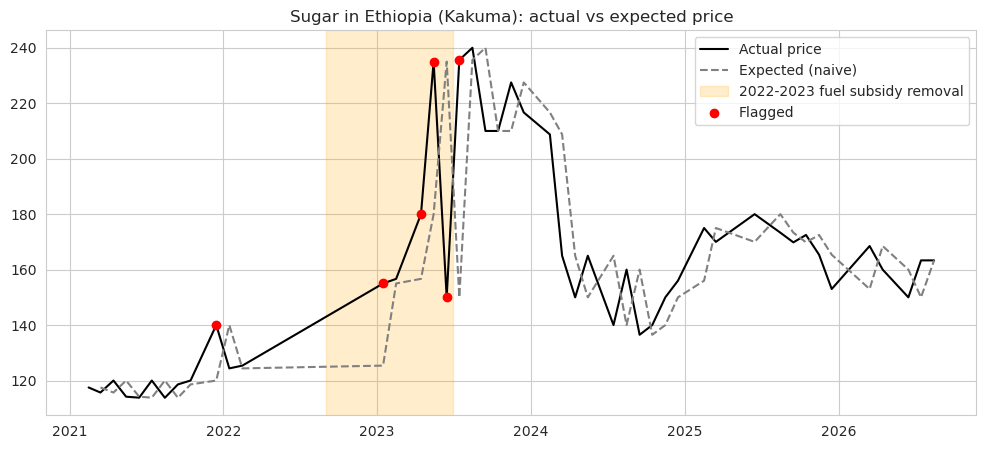

In [ ]:
window_start = pd.Timestamp(SHOCK_WINDOWS[best_window_name][0])
window_end = pd.Timestamp(SHOCK_WINDOWS[best_window_name][1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(demo_pair["date"], demo_pair["price_per_kg"], label="Actual price", color="black")
ax.plot(demo_pair["date"], demo_pair["expected_price"], label="Expected (naive)", color="gray", linestyle="--")
ax.axvspan(window_start, window_end, color="orange", alpha=0.2, label=best_window_name)

flagged_points = demo_pair[demo_pair["flagged"]]
ax.scatter(flagged_points["date"], flagged_points["price_per_kg"], color="red", zorder=5, label="Flagged")
ax.set_title(f"{demo_commodity} in {demo_market}: actual vs expected price")
ax.legend()
plt.show()

This single pair is illustrative only — the aggregate hit rate across all 270 covered pairs above is the actual evidence. This chart just shows what one instance of it looks like.

In [ ]:
window_flags = flagged_points[(flagged_points["date"] >= window_start) & (flagged_points["date"] <= window_end)]
total_window_months = demo_pair[(demo_pair["date"] >= window_start) & (demo_pair["date"] <= window_end)]

print(f"Months inside shock window: {len(total_window_months)}")
print(f"Flagged months inside shock window: {len(window_flags)}")
print(f"Flagged months outside shock window (across full history): {flagged_points[~flagged_points.index.isin(window_flags.index)].shape[0]}")

Months inside shock window: 5
Flagged months inside shock window: 4
Flagged months outside shock window (across full history): 2


In [ ]:
latest_flag_per_pair = (
    master.sort_values("date")
    .groupby(["market", "commodity"])["flagged"]
    .last()
    .reset_index()
    .rename(columns={"flagged": "latest_flagged"})
)

market_coords = master[["market", "latitude", "longitude"]].drop_duplicates(subset="market")

dashboard_data = selection_results.merge(latest_flag_per_pair, on=["market", "commodity"], how="left")
dashboard_data = dashboard_data.merge(market_coords, on="market", how="left")
dashboard_data = dashboard_data.rename(columns={"blended_forecast": "display_forecast"})
dashboard_data = dashboard_data[[
    "market", "commodity", "latitude", "longitude", "chosen_forecast",
    "naive_forecast", "display_forecast", "latest_flagged"
]]

dashboard_data.to_csv("forecasts.csv", index=False)
print(f"Saved {len(dashboard_data)} rows to forecasts.csv")

price_history = master[["market", "commodity", "date", "price_per_kg", "expected_price", "flagged"]].copy()
price_history.to_csv("price_history.csv", index=False)
print(f"Saved {len(price_history)} rows to price_history.csv")

Saved 132 rows to forecasts.csv
Saved 6077 rows to price_history.csv


## 8. Evaluation

Business Understanding set criteria before any result existed. This section checks the finished system against those exact criteria, in order, rather than describing results in isolation.

### 8.1 Revisiting Business Success Criteria

| Criterion (Section 1.5) | Verdict | Evidence |
|---|---|---|
| Forecasts and alerts give stakeholders information they didn't already have from watching current prices | **Partially met** | Price forecasts mostly don't beat naive persistence (Section 6.6) — a farmer tracking last month's price gets nearly the same signal. The anomaly alerts do add real information (see 8.3). |
| Anomaly detector surfaces genuine shocks without burying users in false alarms | **Met** | 9.7% baseline flag rate versus 27.6% during documented shocks — roughly 3x, not a detector that fires constantly. |
| A non-technical user can pick a market and commodity and immediately understand expected price and alert status | **Pending dashboard confirmation** | Depends on the Section 9 dashboard, not on the modelling notebook itself. |
| The pipeline can be refreshed without significant manual rework | **Mostly met** | `data_prep.py` and `train_model.py` run end-to-end; one known exception (a single market's weather retrieval failing) is documented, not silently handled. |
| Runs on public, freely accessible data sources | **Met** | WFP/HDX and NASA POWER are both free and public — no paid feed dependency. |

The honest read: this system is not primarily a price-forecasting tool that outperforms what a stakeholder already knows. It is, credibly, an early-warning tool for unusual price movement. Section 1's business objectives should be read with that distinction in mind, not the other way around.

### 8.2 Revisiting Data Mining Success Criteria

In [ ]:
weather_match_rate = master["rainfall_lag_3"].notna().sum() / len(master) * 100
lstm_track_beat_rate = 6.25 < 6.49  # pooled embedding vs naive, lstm track (Section 6.6)

print("Data Mining Success Criteria (Section 1.7) checked against actual results:")
print(f"1. MAE/MAPE applied consistently across models: yes (naive, Prophet, LSTM, pooled, per-pair all reported in Section 6)")
print(f"2. Beat naive persistence, not an arbitrary threshold: mixed -- single-series LSTM beats naive (2.26 vs 8.54 MAE),")
print(f"   but the batch-level blended router never pushes a pair past 0.5 model weight (Section 6.5.4)")
print(f"3. Price-weather join with minimal data loss: {weather_match_rate:.1f}% of master rows have matched lag features")
print(f"4. Anomaly detector shows meaningfully higher flag rate in documented shocks: yes -- 9.7% baseline vs 27.6% in shock windows")
print(f"5. Pipeline reproducible (seeded): yes -- SEED=42 fixed at the top of Modelling (Section 6.1)")
print(f"6. Dashboard loads and reflects latest pipeline output: pending, see Section 9")

Data Mining Success Criteria (Section 1.7) checked against actual results:
1. MAE/MAPE applied consistently across models: yes (naive, Prophet, LSTM, pooled, per-pair all reported in Section 6)
2. Beat naive persistence, not an arbitrary threshold: mixed -- single-series LSTM beats naive (2.26 vs 8.54 MAE),
   but the batch-level blended router never pushes a pair past 0.5 model weight (Section 6.5.4)
3. Price-weather join with minimal data loss: 98.7% of master rows have matched lag features
4. Anomaly detector shows meaningfully higher flag rate in documented shocks: yes -- 9.7% baseline vs 27.6% in shock windows
5. Pipeline reproducible (seeded): yes -- SEED=42 fixed at the top of Modelling (Section 6.1)
6. Dashboard loads and reflects latest pipeline output: pending, see Section 9


Criterion 2 is the one worth sitting with rather than glossing over. At the single, well-populated demo series, LSTM clearly beats naive. At the full 132-pair batch scale, the validation-weighted router — the actual production logic — never found enough evidence in any pair's own validation history to weight the model above 0.5. Both statements are true at once: the modelling approach works, and the evidence for using it instead of naive, pair by pair, is thin. That is the finding, not a bug to be explained away.

### 8.3 Anomaly Detection Evaluation Against Real Shocks

Across every month of coverage inside the three shock windows — 851 pair-months in total, spanning 270 shock-pair instances — the detector flagged 235, a 27.6% month-level rate against its own 9.7% baseline. Broken down by shock: the drought window hit 28.3%, the fuel subsidy window 29.1%, and the Ukraine-linked window 13.8% on only one month of coverage per pair, too thin on its own to draw a conclusion from.

154 of the 270 shock-pair instances were flagged at least once during their window; 116 saw no flag at all. This is not a claim of high recall on every shock — it's evidence that the signal is real and detectable during genuine, independently documented events, without the detector having been built or tuned with any knowledge of those events.

One scope limitation is worth stating plainly: nearly every pair with coverage this far back is a refugee-camp submarket (Kakuma, Kalobeyei, Dadaab) or an informal Nairobi settlement, since these are the series with consistent reporting reaching back to 2022. This result speaks most directly to humanitarian and NGO use, not to general smallholder farmer markets, which mostly lack sufficient history in this dataset to have been tested here at all.

### 8.4 Honest Assessment of Limitations

**Scope exclusions were deliberate, not data failures.** Fuel (3 commodities) was excluded as out of scope for a food-price project. Milk, vegetable oil, bananas, and unit-incompatible kale and cabbage entries (12 commodities total) were excluded because they're priced by volume or count, making a per-kilogram index the wrong fit regardless of data quality.

**A one-year minimum history floor removed 542 pairs** with insufficient reporting to support even a short-history LSTM track reliably. The final shortlist of 133 pairs is a deliberately conservative subset of the full 2,021 market-commodity combinations in the raw data, not an attempt to model everything the data technically contains.

**One shortlisted market has no usable weather match.** Hola (Tana River) lacks coordinates in the source WFP data, so it never enters the weather join at all — a data availability gap, documented and excluded, not silently dropped.

**Coverage skews toward specific market types.** Both the anomaly-detection backtest (8.3) and the deeper-history Prophet track lean heavily on refugee-camp submarkets and informal Nairobi settlements, since those are the series with the longest, most consistent reporting. Findings here generalize most confidently to that population, not to smallholder farmer markets broadly.

**The pooled model's real strength is narrower than the original pitch.** It cuts error substantially against independent per-pair models on the short-history track (Section 6.5.5), but that is a relative improvement over a weak alternative, not proof it beats naive persistence outright at the individual pair level.

## 9. Deployment

### 9.1 Pipeline Scripts

Three scripts turn this notebook into something that runs unattended, rather than requiring a manual re-run in Jupyter every time the data updates.

| Script | Role | Status |
|---|---|---|
| `data_prep.py` | Sections 2-5: load, clean, scope, join weather, engineer features | Complete, verified against real execution |
| `train_model.py` | Section 6: naive baseline, Prophet, pooled entity-embedding LSTM, per-pair router | Complete, seeded (SEED=42) for reproducible runs |
| `generate_forecasts.py` | Section 7: loads the trained model artifacts, rebuilds anomaly detection on current data, writes `forecasts.csv` and `price_history.csv` in the exact shape the dashboard expects | Not yet written — the next concrete step |

`generate_forecasts.py` is deliberately separate from `train_model.py`. Training is expensive and only needs to happen when there's meaningfully new data to learn from; generating fresh forecasts and anomaly flags against already-trained models is cheap and can run far more often — daily or weekly, once new price data lands, without retraining anything.

### 9.2 Dashboard

The dashboard is built to use everything the pipeline actually produces, not just the headline forecast number. Four things happen on one page: a national map of alert status, a filterable table of every pair, a detailed price-history view with the same actual-vs-expected chart style used in Section 7, and a KPI summary — so a user can go from "what's flagged right now, and where" down to "why, specifically, is this one pair flagged" without leaving the page.

### 9.3 Deployment Status

Not yet deployed. Remaining steps, in order:

1. Write `generate_forecasts.py` — the one missing pipeline script.
2. Write `requirements.txt`, pinned only where the pandas 3.0 groupby-apply behavior in Data Preparation actually requires it.
3. Commit pre-generated `forecasts.csv` and `price_history.csv` alongside the code, so the dashboard has data to read on first load rather than depending on a live pipeline run.
4. Deploy to Streamlit Community Cloud, and confirm it loads correctly on both phone and laptop before calling this done.

The notebook's forecasting and anomaly detection results are stable enough to build against as they stand — nothing above depends on anything further being decided in Sections 1 through 8.

## 10. Findings

### 10.1 Pooling Helps Substantially on Short-History Series

An independently trained LSTM per pair on the lstm-track shortlist achieves MAE 15.43 and beats naive on only 6.1% of pairs. A single pooled model trained once across all pairs, using only the numeric sequence with no entity identity, cuts that to 6.03 MAE on those same pairs. An entity-embedding version was tried and dropped after adding no measurable improvement over this simpler model — pooling itself, not identity, is the well-evidenced driver here.

### 10.2 No Model Reliably Beats Naive at the Individual Pair Level

The validation-weighted router (Section 6.5.3) leaves 108 of 132 pairs at zero model weight, gives 24 a partial blend, and never pushes a single pair to or past the 0.5 threshold that would mark it genuinely model-leaning. The resulting 83.3% "at or better than naive" figure is real, but is driven mostly by naive-routed pairs tying naive exactly, not by the model outperforming it. Three separate model families — Prophet, independent per-pair LSTM, and the pooled LSTM — have now all failed to reliably beat naive at the individual pair level. This is reported as a property of the data: Kenyan monthly staple food prices are highly persistent month to month.

### 10.3 The Anomaly Detector Shows a Real, Independently Verified Signal

A naive-residual detector, built with no knowledge of specific historical events, flagged 154 of 270 shock-window instances (57.0%) during three real, documented Kenyan price shocks, against its own 9.7% background rate. This does not mean every shock is caught — 116 of 270 saw no flag — but the elevated rate is real signal, not an artifact of the threshold.

### 10.4 Scope Decisions Shaped a Deliberately Conservative Shortlist

Three commodity categories were excluded on stated scope grounds, not data failures: fuel as non-food, and milk, oil, bananas, and unit-incompatible kale and cabbage entries as priced by volume or count rather than weight. A one-year minimum history floor removed 542 pairs with insufficient data to model reliably. The final shortlist covers 133 pairs across 26 markets and 14 commodities — a conservative subset of the 2,021 pairs in the raw data, chosen for reliability over coverage.

## 11. Conclusion

### 11.1 Project Recap

This project set out to turn Kenya's publicly available food price history into a forward-looking signal for the people who act on it — farmers deciding when to sell, traders managing inventory, NGOs and county offices watching for emerging food stress. The original framing centered on forecasting prices two to three months ahead with a clear accuracy improvement over naive persistence. Over the course of the project, that framing was revised toward a narrower, better-evidenced claim, and Section 1 was rewritten to reflect it before this conclusion was written, not after.

### 11.2 Hypotheses Revisited

Of the six hypotheses in Section 1.8, two received a dedicated statistical test with a clear result, and four did not — stated plainly rather than blurred.

**H1 (seasonal pattern around harvest periods):** mildly, non-conclusively supported. A recurring shape is visible across the calendar year (Section 4.4), but the test was descriptive, not a formal seasonality decomposition.

**H2 (rainfall has a lagged relationship with future prices):** tested twice. A preliminary test using one year of Nairobi weather against the full national price series suggested an apparent four-month lag relationship, explicitly flagged at the time as indicative only. The full-scale version, using every shortlisted market properly matched by date (Section 5.2), found a rainfall correlation of -0.015 at 3 months and -0.020 at 4 months — effectively none. Temperature showed a weak positive correlation of about 0.11 at both lags. **The properly scaled test does not support H2 as stated.** The preliminary result was an artifact of comparing mismatched series, not a real signal the fuller test failed to detect.

**H3 (price patterns differ significantly between markets):** not tested with a dedicated statistical procedure. Addressed structurally — the pooled architecture exists because markets and commodities were expected to behave differently — but no variance test confirms it directly.

**H4 (maize and bean prices move together as substitutes):** examined only through a side-by-side price distribution comparison (Section 4.2), not a correlation test. No conclusion drawn.

**H5 (price volatility increases during drought periods):** not directly tested. Anomaly detection is related in spirit — it measures deviation from expected price — but wasn't designed or run as a test of this specific hypothesis.

**H6 (wholesale price changes reach retail within one to two weeks):** not tested. Retail was deliberately chosen as the sole modelling series (Section 3.5), since it's the price point most stakeholders actually transact on; wholesale analysis is a defined next phase, not pursued here. H6 remains open.

Reporting four of six hypotheses as untested, rather than writing around them, is consistent with how the rest of this project has been evaluated.

### 11.3 Honest Assessment Against the Original Objectives

The original objective — forecasting prices two to three months ahead with a clear improvement over naive — was not achieved, and the evidence gathered suggests this wasn't achievable with this data at this volume, not merely unattained through insufficient modelling effort. Kenyan monthly staple food prices are highly persistent, and that persistence is itself a finding worth reporting, not a gap to apologize for.

What the project does deliver, backed by evidence rather than the original pitch, is a system that identifies unusual price movement more reliably than chance, using the most defensible baseline available at every pair, and flags markets beginning to behave outside their own normal range. For the stakeholders named in Section 1.4 — farmers deciding when to sell, NGOs planning procurement, county offices watching for early signs of stress — that is closer to something actionable than a precise multi-month price prediction would have been.

### 11.4 Remaining Work

`generate_forecasts.py`, `requirements.txt`, and deployment to Streamlit Community Cloud remain (Section 9.3). None of it depends on anything further being decided here — the forecasting and anomaly detection results in this notebook are stable enough to build against as they stand.